### Invariant of neural representation

- build multivariate gaussian distribution with covariance matrix
- The covariance matrix is built by rotating the original covariance matrix
- The rotation is done by a design matrix B.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from sklearn.decomposition import PCA
from hebbian.utils import rotation_matrix_nd, rotate_cov_nd, eig_sorted, ellipse_xy_from_cov, instantiate_before_after_X, before_after_distribution

In [2]:
N = 64
m = 4
phi_deg = 45.0
n_samples = 10001
X_seed = 0
# get /sigma
#Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
Sigma = np.array([[1.0, 0.2, 0.2, 0.5], [0.2, 1.0, 0.2, 0.5], [0.2, 0.2, 1.0, 0.5], [0.5, 0.5, 0.5, 1.0]])
Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)

# Do PCA on X before and X after
pca_before = PCA(n_components=m)
pca_before.fit(X_before)
X_before_pca = pca_before.transform(X_before)
pca_after = PCA(n_components=m)
pca_after.fit(X_after)
X_after_pca = pca_after.transform(X_after)

# eigen values of X before and X after
print(f"Eigen values of X before: {pca_before.explained_variance_}")
print(f"Eigen values of X after: {pca_after.explained_variance_}")

# variance explained by each PC
print(f"Variance explained by each PC of X before: {pca_before.explained_variance_ratio_}")
print(f"Variance explained by each PC of X after: {pca_after.explained_variance_ratio_}")



Eigen values of X before: [2.09816171 0.80725067 0.79299695 0.31406875]
Eigen values of X after: [2.11567413 0.79720382 0.78755502 0.30671861]
Variance explained by each PC of X before: [0.5229092  0.20118507 0.19763272 0.07827301]
Variance explained by each PC of X after: [0.52797457 0.19894526 0.19653737 0.0765428 ]


### Apply Leen's complete model to before and after drifted models

In [3]:
from hebbian.models import OneShotLeenCompletePCA, OneShotLeenReislebenPCA
from hebbian.utils import Y_aligned_training_testing, Y_aligned_training_testing_online

### Multiple runs

In [4]:
### Two phase training and testing

def bar_graph_with_error_bars(df_best_corr, title):
    figure = plt.figure()
    means = df_best_corr.mean(axis=0)
    stds = df_best_corr.std(axis=0)
    plt.figure(figsize=(10, 6))
    plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
    plt.ylabel('Mean Absolute Correlation')
    plt.title(title)
    plt.show()

def two_phase_training_testing(model, data_before, data_after, m, model_paras_after=None, runs =10, graph = True):
    df_best_corr_after = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])
    df_best_corr_before = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])

    for run in range(runs):
        print(f"run {run+1:2d}")
        print(f"X_before")
        order, similarity = Y_aligned_training_testing_online(model, data_before, graph=True, alignment="cov")
        # print(f"After first phase: model.W = {model.W}, model.V: {model.V}")
        print(f"W after first phase: {model.W}")
        # print(f"Y_output_after_first_phase: {model.transform(data_before)}")
       # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_before.iloc[run, :] = ordered_similarity 

#################################################################
        print(f"X_after")
        # update the model parameters, if provided
        if model_paras_after is not None:
            for key, value in model_paras_after.items():
                if hasattr(model, key):
                    setattr(model, key, value)

        order, similarity = Y_aligned_training_testing_online(model, data_after, graph=True, alignment="cosine")
        print(f"after second phase: model.W = {model.W}")
        try:
            print(f"model.V = {model.V}")
        except AttributeError:
            pass
        # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_after.iloc[run, :] = ordered_similarity
        # print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")
        model.reset()

    if graph == True:
        bar_graph_with_error_bars(df_best_corr_before, "Mean Absolute Correlation (before)")
        bar_graph_with_error_bars(df_best_corr_after, "Mean Absolute Correlation (after)")

### Golden standard: Sanger's rule

run  1
X_before
step    0 | order = [2 1 3 0] | best|corr|= [0.095 0.206 0.017 0.119]
step 1000 | order = [0 1 3 2] | best|corr|= [0.999 0.988 0.049 0.994]
step 2000 | order = [0 1 2 3] | best|corr|= [0.997 0.992 0.995 0.31 ]
step 3000 | order = [0 1 2 3] | best|corr|= [0.989 0.995 0.997 0.996]
step 4000 | order = [0 1 2 3] | best|corr|= [0.993 0.964 0.961 0.995]
step 5000 | order = [0 1 2 3] | best|corr|= [0.995 0.992 0.996 0.999]
step 6000 | order = [0 1 2 3] | best|corr|= [0.997 0.982 0.98  0.998]
step 7000 | order = [0 1 2 3] | best|corr|= [0.992 0.995 0.997 0.999]
step 8000 | order = [0 1 2 3] | best|corr|= [0.987 0.994 0.998 0.997]
step 9000 | order = [0 1 2 3] | best|corr|= [0.998 0.985 0.994 1.   ]
step 10000 | order = [0 1 2 3] | best|corr|= [0.993 0.971 0.947 0.997]


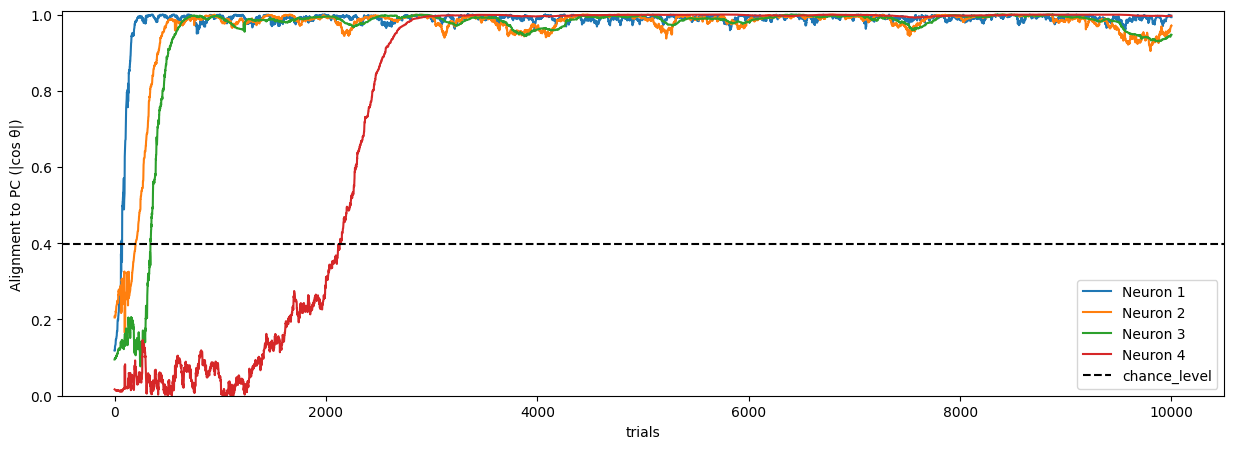

W after first phase: [[-0.11579868 -0.08723468 -0.10548473 -0.09400813  0.11742211  0.16970138
   0.16648233 -0.15500905  0.0559716   0.05884694  0.17541429  0.01544179
   0.04169162  0.22015504 -0.06857029 -0.02881936  0.01868637 -0.03719253
  -0.02710921  0.14760163 -0.0612493   0.31855303 -0.039023   -0.06624771
  -0.14633707  0.11220148  0.1388383   0.02603463  0.14402131  0.03404133
  -0.06829287  0.08292128 -0.05352216  0.02686685 -0.17296366 -0.04092911
   0.24994785  0.07205924 -0.22318702  0.18704854 -0.06337975  0.08313847
  -0.03466437  0.18219015  0.00751916  0.00906354  0.10709472 -0.14847793
  -0.07186101  0.01410334 -0.01313994 -0.12119886  0.02233465  0.12807565
  -0.07569449  0.05692073 -0.11455441  0.06197095  0.05360402 -0.00215333
   0.42966037 -0.00536848  0.02872465  0.20979874]
 [ 0.0234071   0.14413352 -0.02989518  0.01186964  0.12852739 -0.29057376
  -0.29355057 -0.00093536 -0.06521663 -0.05963544  0.1188279  -0.0428418
  -0.22419439 -0.16702581  0.05661911  0.

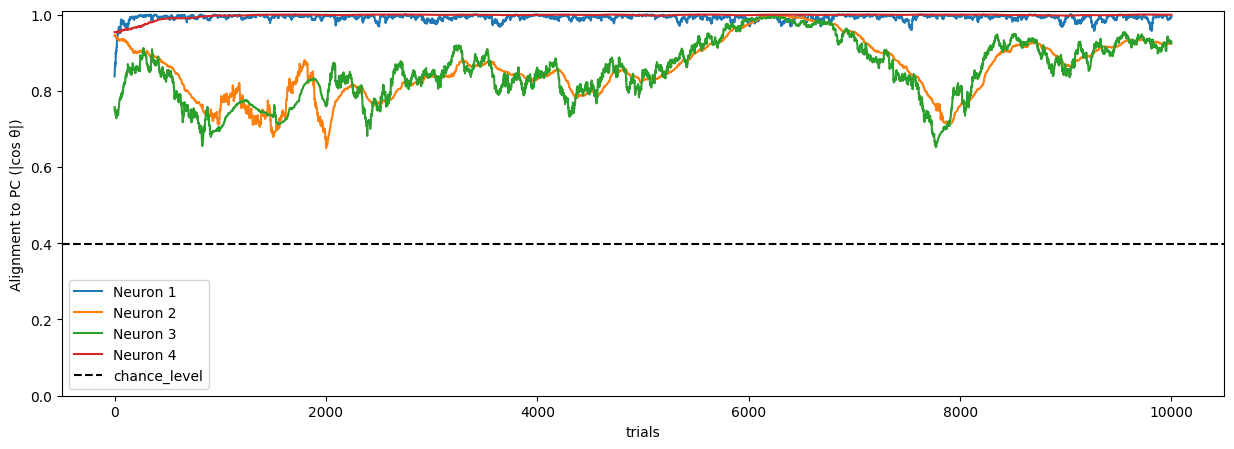

after second phase: model.W = [[-1.43261443e-01 -4.35643897e-02 -1.92371929e-02 -3.76434944e-02
   2.16676702e-01  1.86587237e-02 -3.55508806e-02 -1.63049063e-01
   7.43931813e-02 -3.42325491e-03  1.76556198e-01  4.25771188e-02
  -7.28146997e-02  7.04530290e-02 -3.97832233e-02  7.68793411e-02
   3.77543301e-02 -4.80477526e-02  1.91878916e-02  5.83971551e-02
  -1.32511795e-01  2.73181710e-01  2.57299082e-02  6.94179807e-02
  -1.75568118e-01  1.08740975e-01  2.13860840e-01 -4.82151904e-02
   3.09527728e-02  6.02293259e-02 -1.50674833e-02  5.27348589e-02
  -5.39954899e-02  7.56420762e-02 -2.67115913e-01 -6.01489879e-02
   1.96838290e-01  8.98610916e-02 -2.73276381e-01  2.19804732e-01
  -1.28138115e-02  2.07851751e-01  1.66107776e-02  3.66864662e-02
   6.16934073e-02  3.51874775e-02  1.22252705e-01 -1.72979487e-01
  -6.14709051e-02  1.67919239e-02 -4.04192802e-02 -1.23510787e-01
   3.05666607e-02 -1.93304082e-02  1.31681397e-02  1.17340536e-01
  -1.17136099e-02 -3.22159189e-02  1.90217196e

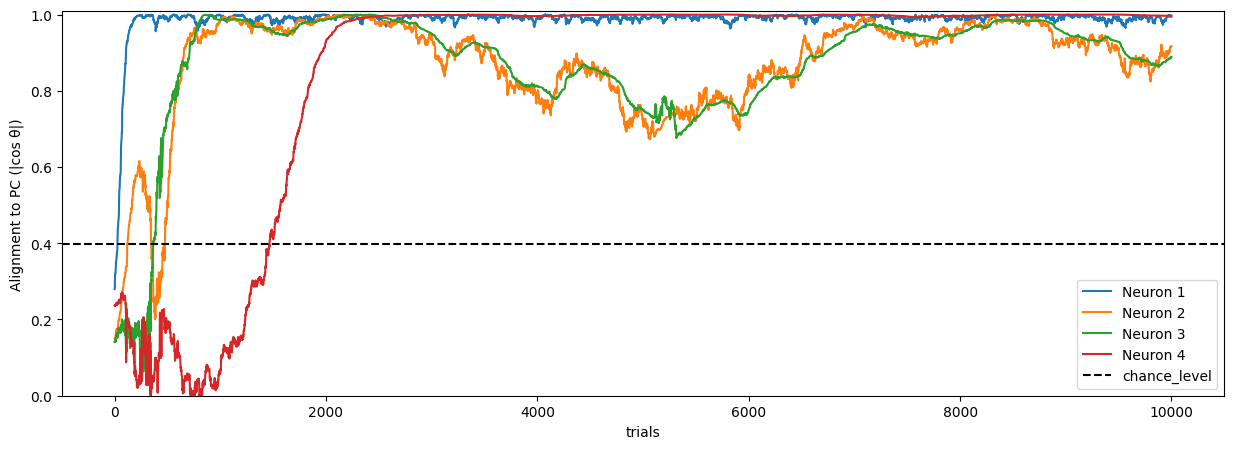

W after first phase: [[ 0.11258859  0.08482775  0.09814229  0.08832245 -0.11455799 -0.16259203
  -0.15736194  0.15002301 -0.05670505 -0.05442678 -0.16564954 -0.01465949
  -0.03912081 -0.20816698  0.06537053  0.02423934 -0.01683325  0.0342541
   0.02710778 -0.13972779  0.05816916 -0.30147602  0.03451841  0.06042468
   0.14369707 -0.10701161 -0.13480718 -0.0264407  -0.13439383 -0.03139686
   0.06481676 -0.07743647  0.05256761 -0.02757359  0.16741565  0.04036669
  -0.23881131 -0.06826088  0.2140946  -0.18149481  0.05932912 -0.08188742
   0.03326442 -0.17104887 -0.00757141 -0.00582486 -0.10156232  0.14224554
   0.07139735 -0.01295534  0.01103001  0.11560493 -0.02317363 -0.11960977
   0.07165077 -0.05433388  0.10531742 -0.05678634 -0.05242808  0.00324019
  -0.40834637  0.00367554 -0.02739023 -0.20073814]
 [ 0.04921804  0.15525729 -0.06576678 -0.00682295  0.09164059 -0.28098902
  -0.25774412  0.01953515 -0.0961672  -0.03937585  0.13010118 -0.05343909
  -0.20703415 -0.13609775  0.05524009  0.

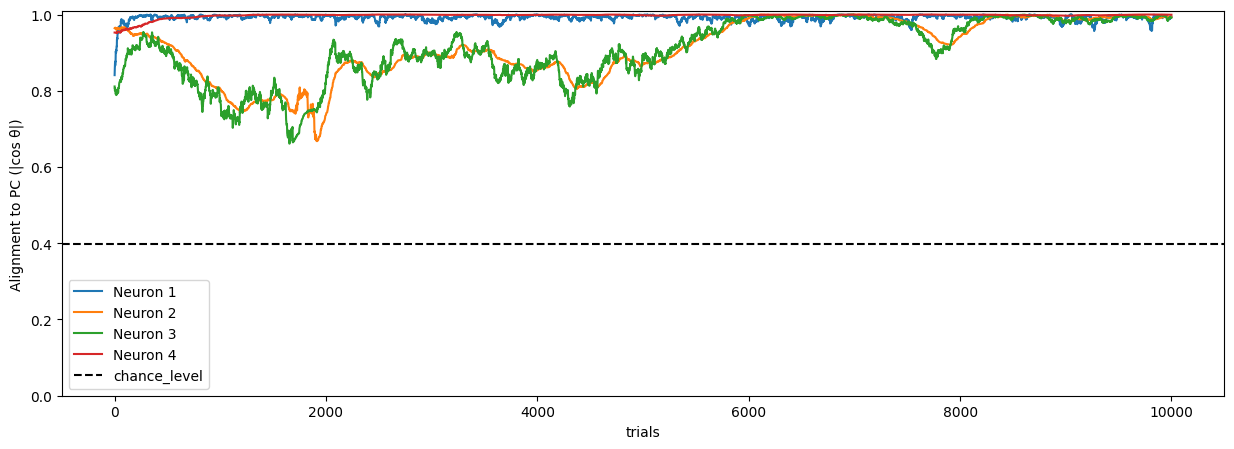

after second phase: model.W = [[ 0.14326144  0.04356439  0.01923719  0.03764349 -0.2166767  -0.01865872
   0.03555088  0.16304906 -0.07439318  0.00342325 -0.1765562  -0.04257712
   0.0728147  -0.07045303  0.03978322 -0.07687934 -0.03775433  0.04804775
  -0.01918789 -0.05839716  0.1325118  -0.27318171 -0.02572991 -0.06941798
   0.17556812 -0.10874098 -0.21386084  0.04821519 -0.03095277 -0.06022933
   0.01506748 -0.05273486  0.05399549 -0.07564208  0.26711591  0.06014899
  -0.19683829 -0.08986109  0.27327638 -0.21980473  0.01281381 -0.20785175
  -0.01661078 -0.03668647 -0.06169341 -0.03518748 -0.12225271  0.17297949
   0.06147091 -0.01679192  0.04041928  0.12351079 -0.03056666  0.01933041
  -0.01316814 -0.11734054  0.01171361  0.03221592 -0.01902172 -0.03461679
  -0.41044072 -0.00281239 -0.00476048 -0.06523324]
 [ 0.12263282  0.19885299 -0.06517809 -0.00483477 -0.01545052 -0.31633322
  -0.24594765  0.12511716 -0.18813455 -0.0047402   0.10466622 -0.01840259
  -0.17103297 -0.14112463  0.06

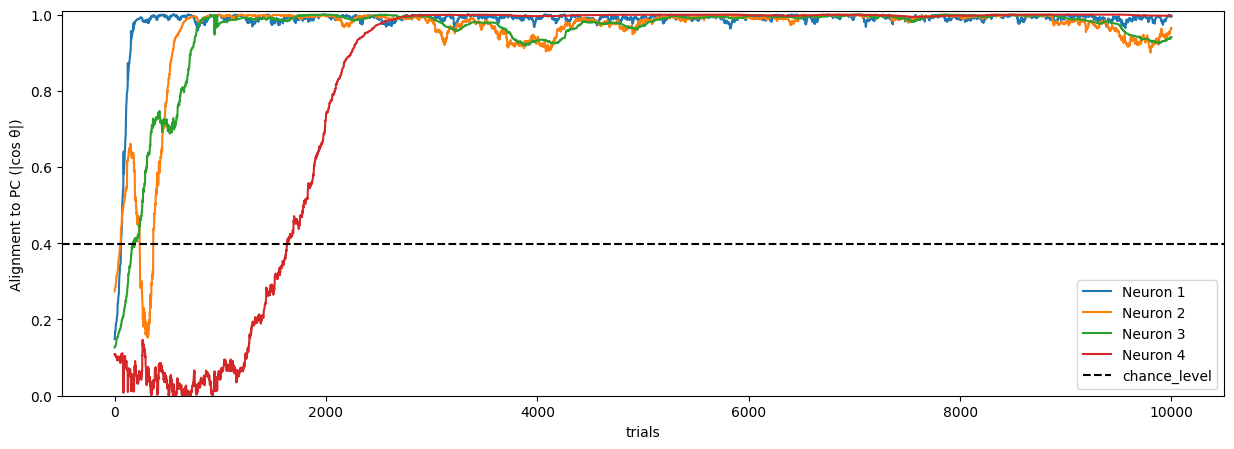

W after first phase: [[-0.11258859 -0.08482775 -0.09814229 -0.08832245  0.11455799  0.16259203
   0.15736194 -0.15002301  0.05670505  0.05442678  0.16564954  0.01465949
   0.03912081  0.20816698 -0.06537053 -0.02423934  0.01683325 -0.0342541
  -0.02710778  0.13972779 -0.05816916  0.30147602 -0.03451841 -0.06042468
  -0.14369707  0.10701161  0.13480718  0.0264407   0.13439383  0.03139686
  -0.06481676  0.07743647 -0.05256761  0.02757359 -0.16741565 -0.04036669
   0.23881131  0.06826088 -0.2140946   0.18149481 -0.05932912  0.08188742
  -0.03326442  0.17104887  0.00757141  0.00582486  0.10156232 -0.14224554
  -0.07139735  0.01295534 -0.01103001 -0.11560493  0.02317363  0.11960977
  -0.07165077  0.05433388 -0.10531742  0.05678634  0.05242808 -0.00324019
   0.40834637 -0.00367554  0.02739023  0.20073814]
 [-0.02622238 -0.1405253   0.03327069 -0.0088705  -0.11823261  0.27871677
   0.27771391 -0.00273891  0.06796506  0.0540764  -0.11634505  0.04137485
   0.21309458  0.1562965  -0.05410868 -0.

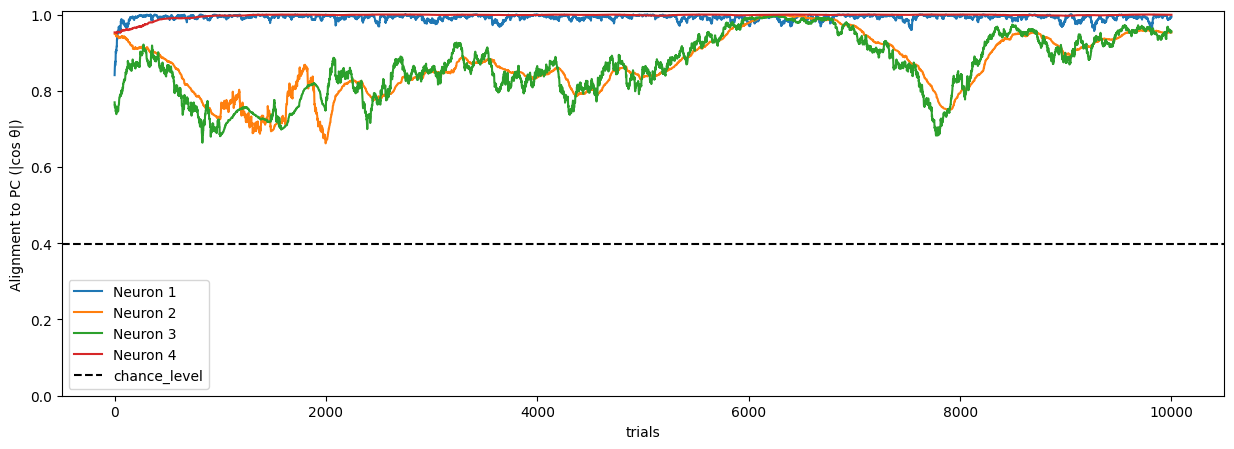

after second phase: model.W = [[-1.43261443e-01 -4.35643897e-02 -1.92371929e-02 -3.76434944e-02
   2.16676702e-01  1.86587237e-02 -3.55508806e-02 -1.63049063e-01
   7.43931813e-02 -3.42325491e-03  1.76556198e-01  4.25771188e-02
  -7.28146997e-02  7.04530290e-02 -3.97832233e-02  7.68793411e-02
   3.77543301e-02 -4.80477526e-02  1.91878916e-02  5.83971551e-02
  -1.32511795e-01  2.73181710e-01  2.57299082e-02  6.94179807e-02
  -1.75568118e-01  1.08740975e-01  2.13860840e-01 -4.82151904e-02
   3.09527728e-02  6.02293259e-02 -1.50674833e-02  5.27348589e-02
  -5.39954899e-02  7.56420762e-02 -2.67115913e-01 -6.01489879e-02
   1.96838290e-01  8.98610916e-02 -2.73276381e-01  2.19804732e-01
  -1.28138115e-02  2.07851751e-01  1.66107776e-02  3.66864662e-02
   6.16934073e-02  3.51874775e-02  1.22252705e-01 -1.72979487e-01
  -6.14709051e-02  1.67919239e-02 -4.04192802e-02 -1.23510787e-01
   3.05666607e-02 -1.93304082e-02  1.31681397e-02  1.17340536e-01
  -1.17136099e-02 -3.22159189e-02  1.90217196e

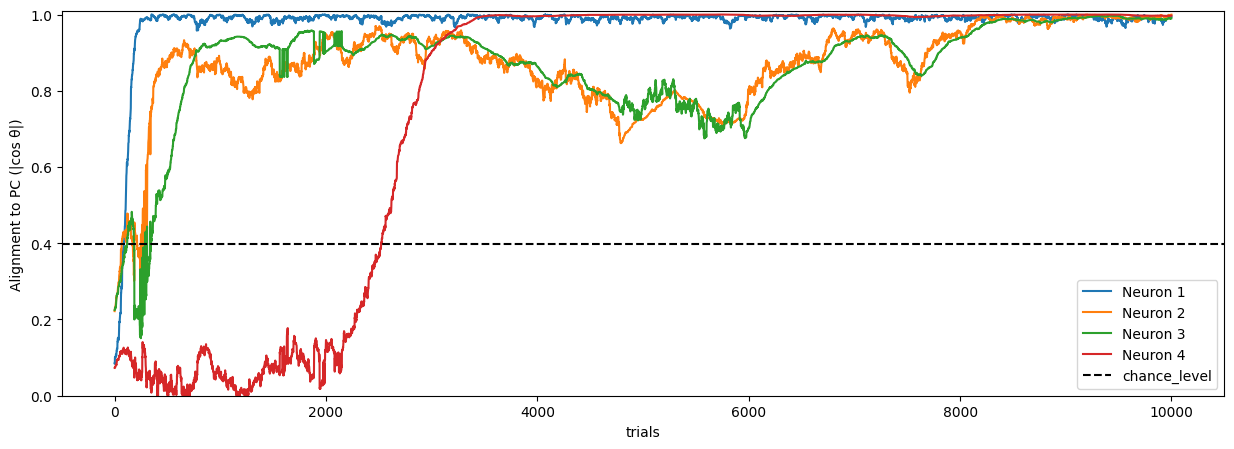

W after first phase: [[ 1.12588588e-01  8.48277544e-02  9.81422944e-02  8.83224496e-02
  -1.14557995e-01 -1.62592025e-01 -1.57361943e-01  1.50023013e-01
  -5.67050455e-02 -5.44267840e-02 -1.65649539e-01 -1.46594855e-02
  -3.91208058e-02 -2.08166981e-01  6.53705321e-02  2.42393422e-02
  -1.68332541e-02  3.42540970e-02  2.71077791e-02 -1.39727789e-01
   5.81691583e-02 -3.01476020e-01  3.45184141e-02  6.04246781e-02
   1.43697066e-01 -1.07011612e-01 -1.34807176e-01 -2.64407029e-02
  -1.34393835e-01 -3.13968580e-02  6.48167615e-02 -7.74364709e-02
   5.25676108e-02 -2.75735929e-02  1.67415654e-01  4.03666948e-02
  -2.38811312e-01 -6.82608832e-02  2.14094599e-01 -1.81494809e-01
   5.93291219e-02 -8.18874246e-02  3.32644161e-02 -1.71048875e-01
  -7.57140863e-03 -5.82486167e-03 -1.01562318e-01  1.42245545e-01
   7.13973464e-02 -1.29553364e-02  1.10300122e-02  1.15604933e-01
  -2.31736316e-02 -1.19609765e-01  7.16507683e-02 -5.43338753e-02
   1.05317420e-01 -5.67863415e-02 -5.24280802e-02  3.24

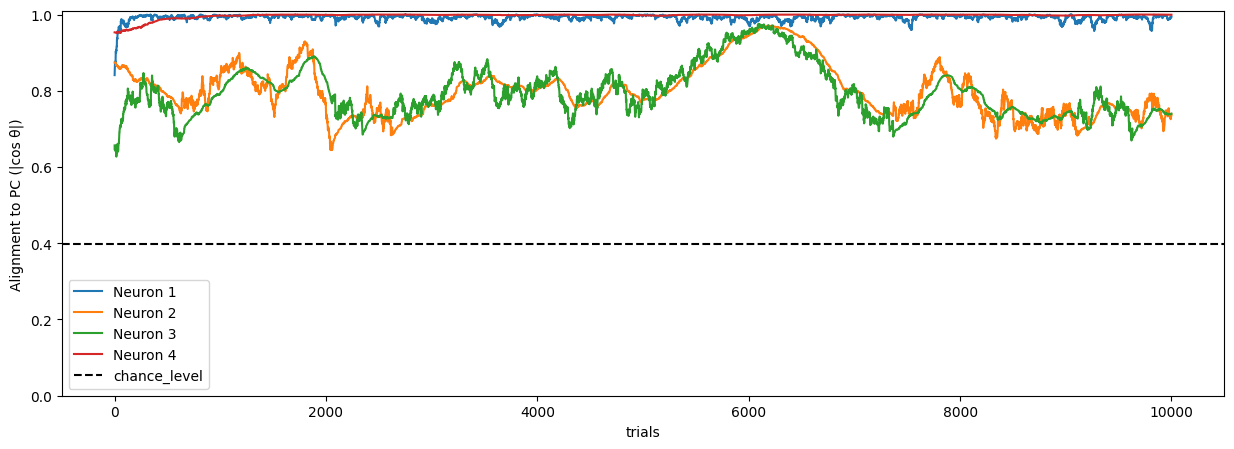

after second phase: model.W = [[ 0.14326144  0.04356439  0.01923719  0.03764349 -0.2166767  -0.01865872
   0.03555088  0.16304906 -0.07439318  0.00342325 -0.1765562  -0.04257712
   0.0728147  -0.07045303  0.03978322 -0.07687934 -0.03775433  0.04804775
  -0.01918789 -0.05839716  0.1325118  -0.27318171 -0.02572991 -0.06941798
   0.17556812 -0.10874098 -0.21386084  0.04821519 -0.03095277 -0.06022933
   0.01506748 -0.05273486  0.05399549 -0.07564208  0.26711591  0.06014899
  -0.19683829 -0.08986109  0.27327638 -0.21980473  0.01281381 -0.20785175
  -0.01661078 -0.03668647 -0.06169341 -0.03518748 -0.12225271  0.17297949
   0.06147091 -0.01679192  0.04041928  0.12351079 -0.03056666  0.01933041
  -0.01316814 -0.11734054  0.01171361  0.03221592 -0.01902172 -0.03461679
  -0.41044072 -0.00281239 -0.00476048 -0.06523324]
 [-0.00305217  0.10050315  0.14260465  0.09581443  0.10757532 -0.27809715
  -0.33699821  0.04520547 -0.02062308 -0.08733832 -0.01243236  0.05996722
  -0.17644367 -0.25795739  0.05

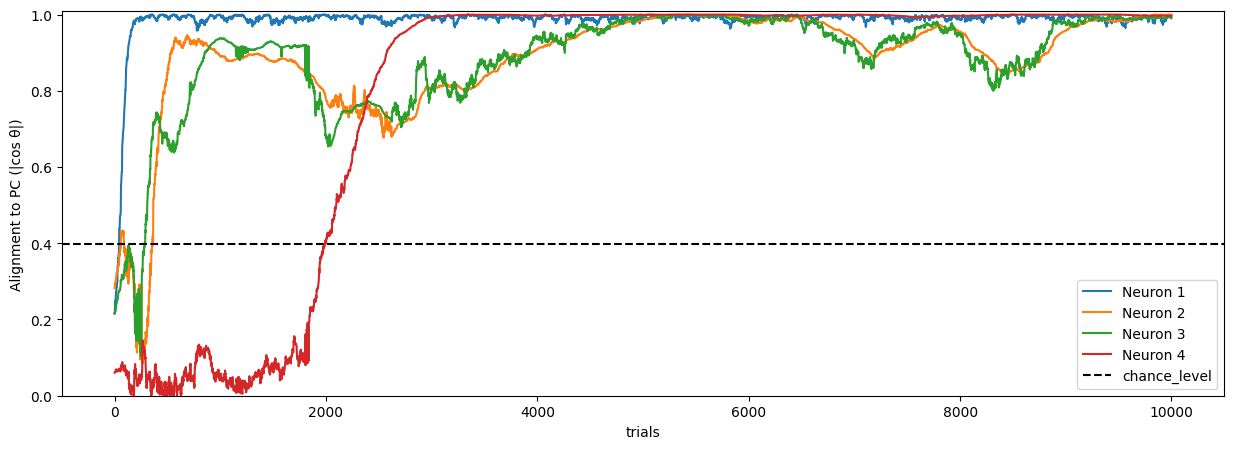

W after first phase: [[-1.12588588e-01 -8.48277544e-02 -9.81422944e-02 -8.83224496e-02
   1.14557995e-01  1.62592025e-01  1.57361943e-01 -1.50023013e-01
   5.67050455e-02  5.44267840e-02  1.65649539e-01  1.46594855e-02
   3.91208058e-02  2.08166981e-01 -6.53705321e-02 -2.42393422e-02
   1.68332541e-02 -3.42540970e-02 -2.71077791e-02  1.39727789e-01
  -5.81691583e-02  3.01476020e-01 -3.45184141e-02 -6.04246781e-02
  -1.43697066e-01  1.07011612e-01  1.34807176e-01  2.64407029e-02
   1.34393835e-01  3.13968580e-02 -6.48167615e-02  7.74364709e-02
  -5.25676108e-02  2.75735929e-02 -1.67415654e-01 -4.03666948e-02
   2.38811312e-01  6.82608832e-02 -2.14094599e-01  1.81494809e-01
  -5.93291219e-02  8.18874246e-02 -3.32644161e-02  1.71048875e-01
   7.57140863e-03  5.82486167e-03  1.01562318e-01 -1.42245545e-01
  -7.13973464e-02  1.29553364e-02 -1.10300122e-02 -1.15604933e-01
   2.31736316e-02  1.19609765e-01 -7.16507683e-02  5.43338753e-02
  -1.05317420e-01  5.67863415e-02  5.24280802e-02 -3.24

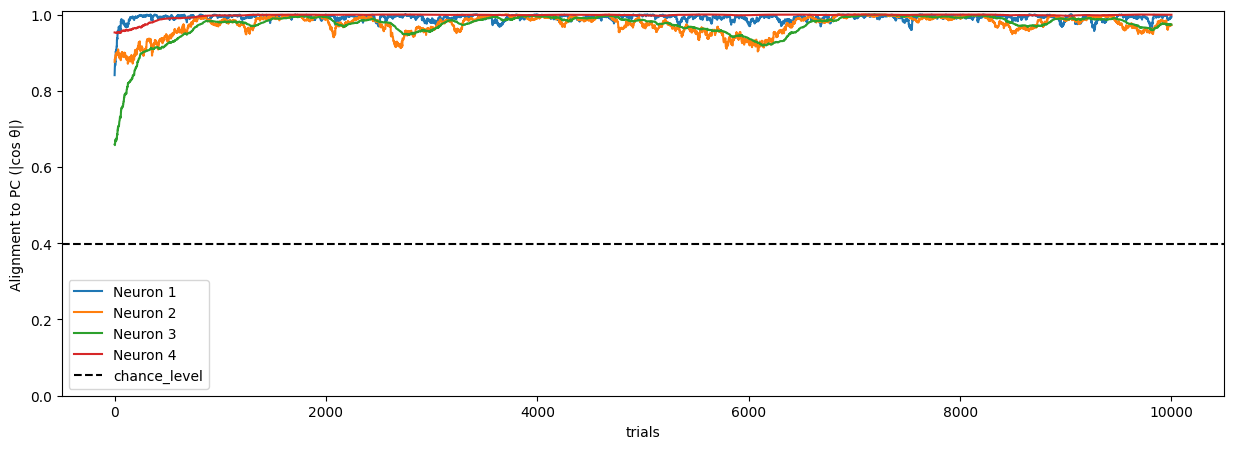

after second phase: model.W = [[-0.14326144 -0.04356439 -0.01923719 -0.03764349  0.2166767   0.01865872
  -0.03555088 -0.16304906  0.07439318 -0.00342325  0.1765562   0.04257712
  -0.0728147   0.07045303 -0.03978322  0.07687934  0.03775433 -0.04804775
   0.01918789  0.05839716 -0.1325118   0.27318171  0.02572991  0.06941798
  -0.17556812  0.10874098  0.21386084 -0.04821519  0.03095277  0.06022933
  -0.01506748  0.05273486 -0.05399549  0.07564208 -0.26711591 -0.06014899
   0.19683829  0.08986109 -0.27327638  0.21980473 -0.01281381  0.20785175
   0.01661078  0.03668647  0.06169341  0.03518748  0.12225271 -0.17297949
  -0.06147091  0.01679192 -0.04041928 -0.12351079  0.03056666 -0.01933041
   0.01316814  0.11734054 -0.01171361 -0.03221592  0.01902172  0.03461679
   0.41044072  0.00281239  0.00476048  0.06523324]
 [-0.13063595 -0.08455102  0.23961344  0.12064157  0.14580678 -0.00816961
  -0.15210704 -0.07491883  0.16981405 -0.10046166 -0.12332286  0.0915207
  -0.03586341 -0.16520604  0.000

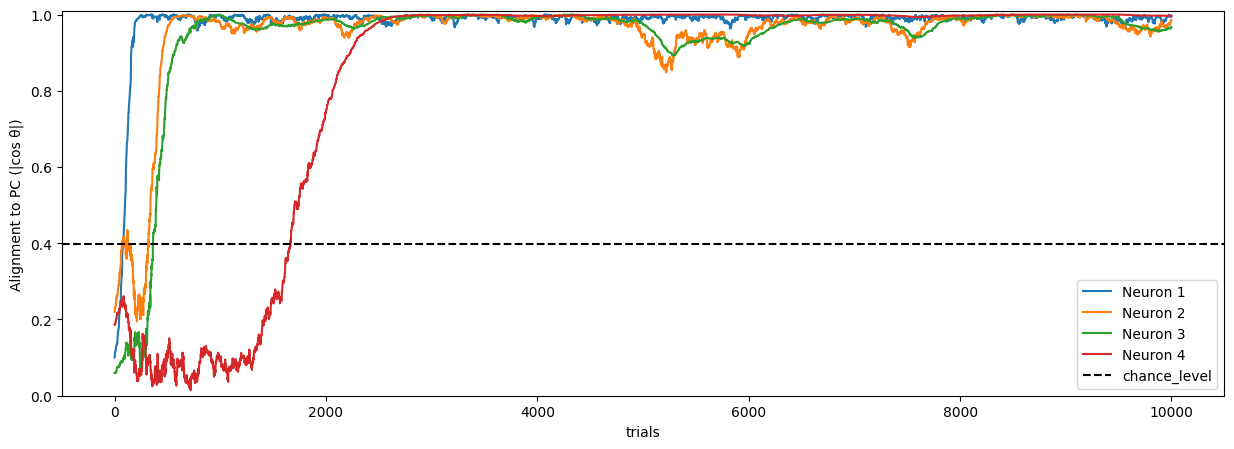

W after first phase: [[-0.11258859 -0.08482775 -0.09814229 -0.08832245  0.11455799  0.16259203
   0.15736194 -0.15002301  0.05670505  0.05442678  0.16564954  0.01465949
   0.03912081  0.20816698 -0.06537053 -0.02423934  0.01683325 -0.0342541
  -0.02710778  0.13972779 -0.05816916  0.30147602 -0.03451841 -0.06042468
  -0.14369707  0.10701161  0.13480718  0.0264407   0.13439383  0.03139686
  -0.06481676  0.07743647 -0.05256761  0.02757359 -0.16741565 -0.04036669
   0.23881131  0.06826088 -0.2140946   0.18149481 -0.05932912  0.08188742
  -0.03326442  0.17104887  0.00757141  0.00582486  0.10156232 -0.14224554
  -0.07139735  0.01295534 -0.01103001 -0.11560493  0.02317363  0.11960977
  -0.07165077  0.05433388 -0.10531742  0.05678634  0.05242808 -0.00324019
   0.40834637 -0.00367554  0.02739023  0.20073814]
 [ 0.01028724  0.12878478 -0.01080148  0.01940776  0.13481411 -0.27371725
  -0.28781873 -0.00868934 -0.0479931  -0.06337281  0.10558043 -0.03265398
  -0.21455942 -0.168055    0.05266412  0.

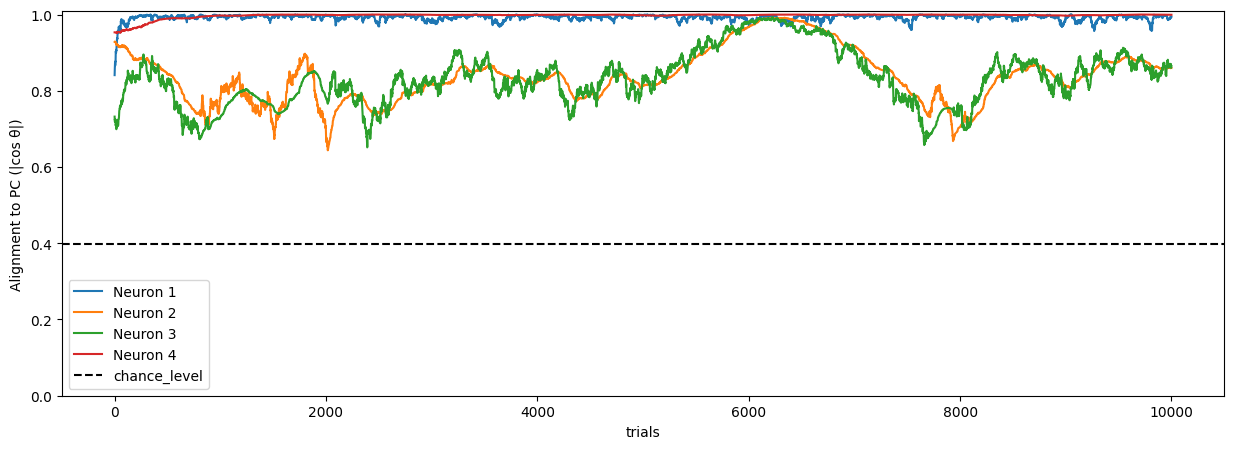

after second phase: model.W = [[-1.43261443e-01 -4.35643897e-02 -1.92371929e-02 -3.76434944e-02
   2.16676702e-01  1.86587237e-02 -3.55508806e-02 -1.63049063e-01
   7.43931813e-02 -3.42325491e-03  1.76556198e-01  4.25771188e-02
  -7.28146997e-02  7.04530290e-02 -3.97832233e-02  7.68793411e-02
   3.77543301e-02 -4.80477526e-02  1.91878916e-02  5.83971551e-02
  -1.32511795e-01  2.73181710e-01  2.57299082e-02  6.94179807e-02
  -1.75568118e-01  1.08740975e-01  2.13860840e-01 -4.82151904e-02
   3.09527728e-02  6.02293259e-02 -1.50674833e-02  5.27348589e-02
  -5.39954899e-02  7.56420762e-02 -2.67115913e-01 -6.01489879e-02
   1.96838290e-01  8.98610916e-02 -2.73276381e-01  2.19804732e-01
  -1.28138115e-02  2.07851751e-01  1.66107776e-02  3.66864662e-02
   6.16934073e-02  3.51874775e-02  1.22252705e-01 -1.72979487e-01
  -6.14709051e-02  1.67919239e-02 -4.04192802e-02 -1.23510787e-01
   3.05666607e-02 -1.93304082e-02  1.31681397e-02  1.17340536e-01
  -1.17136099e-02 -3.22159189e-02  1.90217196e

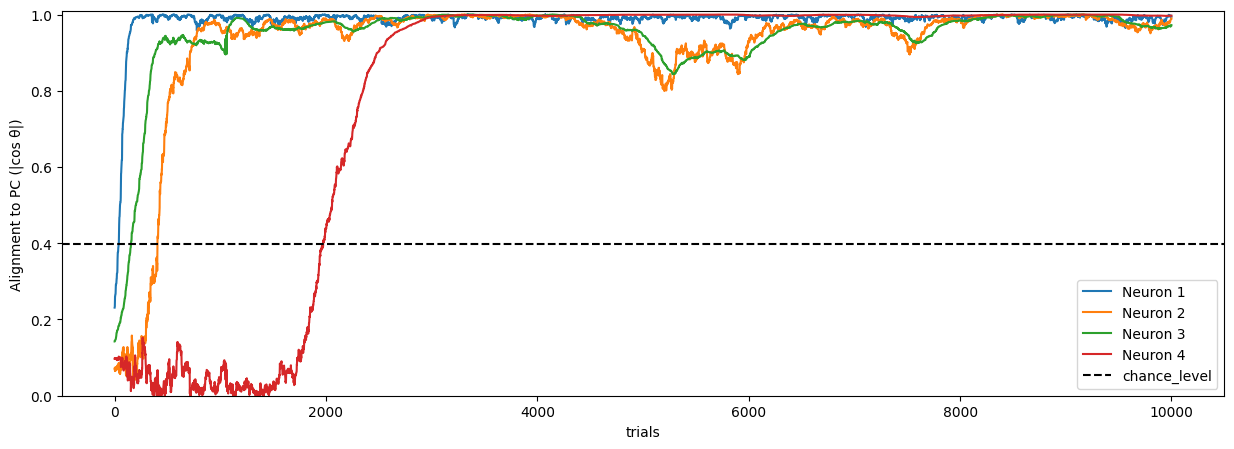

W after first phase: [[ 0.11258859  0.08482775  0.09814229  0.08832245 -0.11455799 -0.16259203
  -0.15736194  0.15002301 -0.05670505 -0.05442678 -0.16564954 -0.01465949
  -0.03912081 -0.20816698  0.06537053  0.02423934 -0.01683325  0.0342541
   0.02710778 -0.13972779  0.05816916 -0.30147602  0.03451841  0.06042468
   0.14369707 -0.10701161 -0.13480718 -0.0264407  -0.13439383 -0.03139686
   0.06481676 -0.07743647  0.05256761 -0.02757359  0.16741565  0.04036669
  -0.23881131 -0.06826088  0.2140946  -0.18149481  0.05932912 -0.08188742
   0.03326442 -0.17104887 -0.00757141 -0.00582486 -0.10156232  0.14224554
   0.07139735 -0.01295534  0.01103001  0.11560493 -0.02317363 -0.11960977
   0.07165077 -0.05433388  0.10531742 -0.05678634 -0.05242808  0.00324019
  -0.40834637  0.00367554 -0.02739023 -0.20073814]
 [ 0.00634939  0.12569787 -0.00525501  0.0219707   0.13868801 -0.2720667
  -0.28986329 -0.0114879  -0.04300576 -0.06556213  0.1027711  -0.03045515
  -0.21458997 -0.17068934  0.05222707  0.1

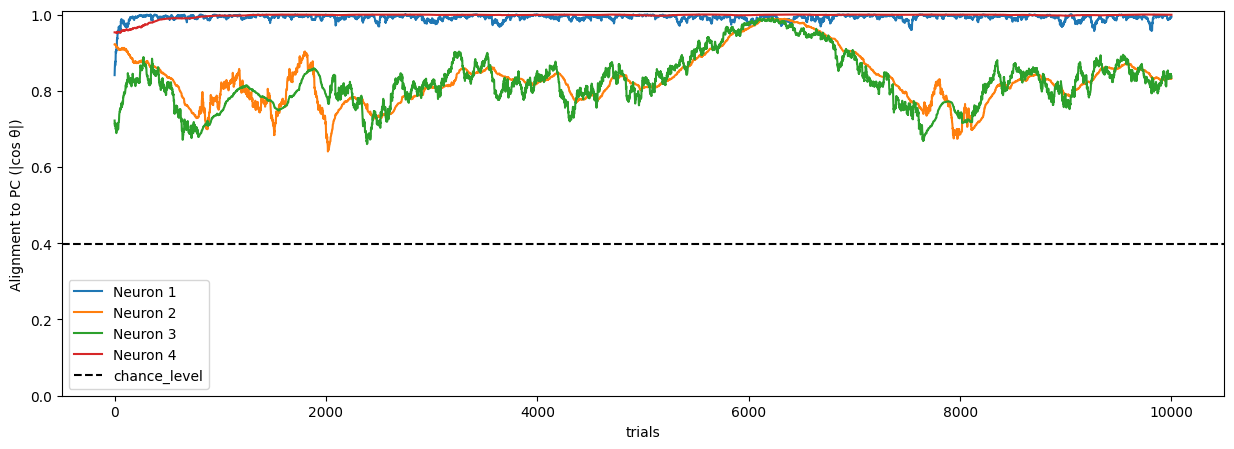

after second phase: model.W = [[ 0.14326144  0.04356439  0.01923719  0.03764349 -0.2166767  -0.01865872
   0.03555088  0.16304906 -0.07439318  0.00342325 -0.1765562  -0.04257712
   0.0728147  -0.07045303  0.03978322 -0.07687934 -0.03775433  0.04804775
  -0.01918789 -0.05839716  0.1325118  -0.27318171 -0.02572991 -0.06941798
   0.17556812 -0.10874098 -0.21386084  0.04821519 -0.03095277 -0.06022933
   0.01506748 -0.05273486  0.05399549 -0.07564208  0.26711591  0.06014899
  -0.19683829 -0.08986109  0.27327638 -0.21980473  0.01281381 -0.20785175
  -0.01661078 -0.03668647 -0.06169341 -0.03518748 -0.12225271  0.17297949
   0.06147091 -0.01679192  0.04041928  0.12351079 -0.03056666  0.01933041
  -0.01316814 -0.11734054  0.01171361  0.03221592 -0.01902172 -0.03461679
  -0.41044072 -0.00281239 -0.00476048 -0.06523324]
 [ 0.0372054   0.1415209   0.0887411   0.07220942  0.07786723 -0.31615425
  -0.33881158  0.07512123 -0.07652012 -0.06880605  0.02417337  0.04015522
  -0.19105136 -0.24415333  0.06

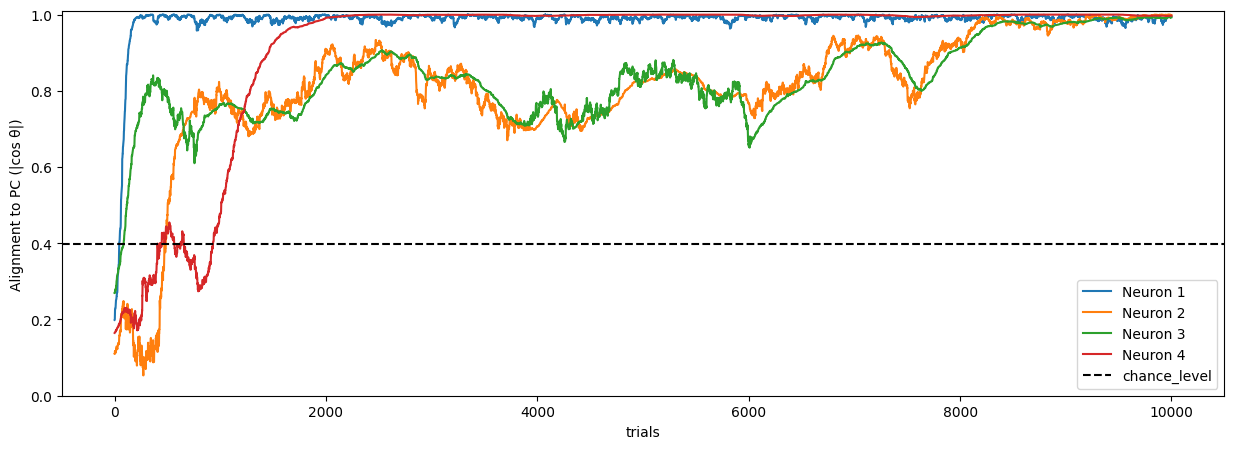

W after first phase: [[ 0.11258859  0.08482775  0.09814229  0.08832245 -0.11455799 -0.16259203
  -0.15736194  0.15002301 -0.05670505 -0.05442678 -0.16564954 -0.01465949
  -0.03912081 -0.20816698  0.06537053  0.02423934 -0.01683325  0.0342541
   0.02710778 -0.13972779  0.05816916 -0.30147602  0.03451841  0.06042468
   0.14369707 -0.10701161 -0.13480718 -0.0264407  -0.13439383 -0.03139686
   0.06481676 -0.07743647  0.05256761 -0.02757359  0.16741565  0.04036669
  -0.23881131 -0.06826088  0.2140946  -0.18149481  0.05932912 -0.08188742
   0.03326442 -0.17104887 -0.00757141 -0.00582486 -0.10156232  0.14224554
   0.07139735 -0.01295534  0.01103001  0.11560493 -0.02317363 -0.11960977
   0.07165077 -0.05433388  0.10531742 -0.05678634 -0.05242808  0.00324019
  -0.40834637  0.00367554 -0.02739023 -0.20073814]
 [-0.02623019  0.09735768  0.04054074  0.0425567   0.16736429 -0.25214805
  -0.29995153 -0.03425764 -0.00095812 -0.08204751  0.0772761  -0.0116064
  -0.20984304 -0.18839071  0.04740366  0.1

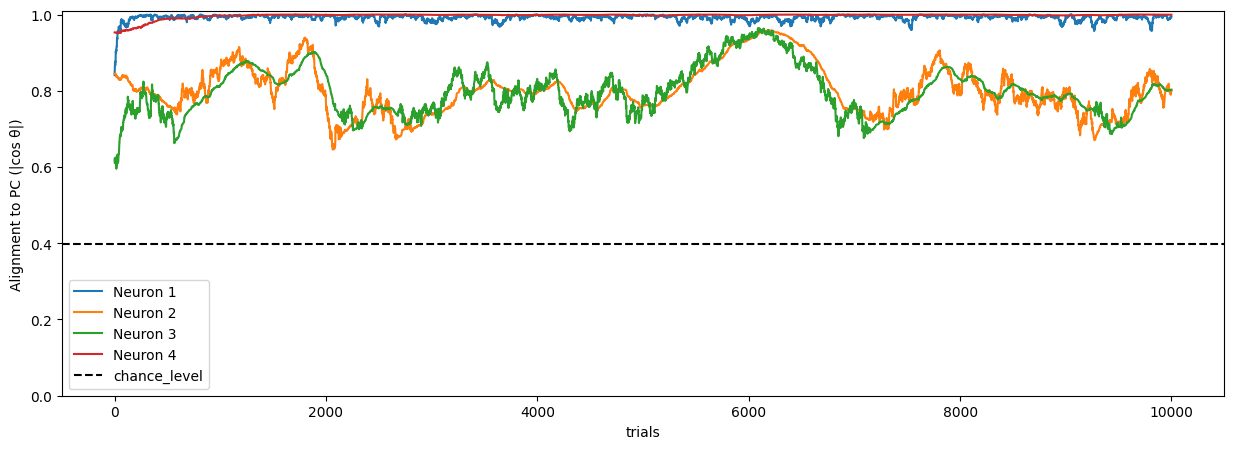

after second phase: model.W = [[ 1.43261443e-01  4.35643897e-02  1.92371929e-02  3.76434944e-02
  -2.16676702e-01 -1.86587237e-02  3.55508806e-02  1.63049063e-01
  -7.43931813e-02  3.42325491e-03 -1.76556198e-01 -4.25771188e-02
   7.28146997e-02 -7.04530290e-02  3.97832233e-02 -7.68793411e-02
  -3.77543301e-02  4.80477526e-02 -1.91878916e-02 -5.83971551e-02
   1.32511795e-01 -2.73181710e-01 -2.57299082e-02 -6.94179807e-02
   1.75568118e-01 -1.08740975e-01 -2.13860840e-01  4.82151904e-02
  -3.09527728e-02 -6.02293259e-02  1.50674833e-02 -5.27348589e-02
   5.39954899e-02 -7.56420762e-02  2.67115913e-01  6.01489879e-02
  -1.96838290e-01 -8.98610916e-02  2.73276381e-01 -2.19804732e-01
   1.28138115e-02 -2.07851751e-01 -1.66107776e-02 -3.66864662e-02
  -6.16934073e-02 -3.51874775e-02 -1.22252705e-01  1.72979487e-01
   6.14709051e-02 -1.67919239e-02  4.04192802e-02  1.23510787e-01
  -3.05666607e-02  1.93304082e-02 -1.31681397e-02 -1.17340536e-01
   1.17136099e-02  3.22159189e-02 -1.90217196e

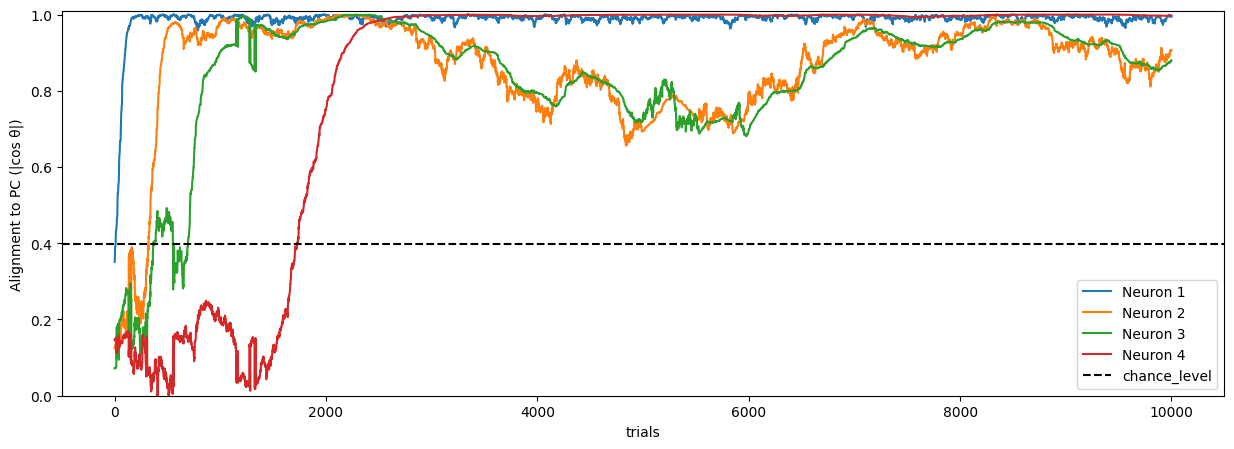

W after first phase: [[-1.12588588e-01 -8.48277544e-02 -9.81422944e-02 -8.83224496e-02
   1.14557995e-01  1.62592025e-01  1.57361943e-01 -1.50023013e-01
   5.67050455e-02  5.44267840e-02  1.65649539e-01  1.46594855e-02
   3.91208058e-02  2.08166981e-01 -6.53705321e-02 -2.42393422e-02
   1.68332541e-02 -3.42540970e-02 -2.71077791e-02  1.39727789e-01
  -5.81691583e-02  3.01476020e-01 -3.45184141e-02 -6.04246781e-02
  -1.43697066e-01  1.07011612e-01  1.34807176e-01  2.64407029e-02
   1.34393835e-01  3.13968580e-02 -6.48167615e-02  7.74364709e-02
  -5.25676108e-02  2.75735929e-02 -1.67415654e-01 -4.03666948e-02
   2.38811312e-01  6.82608832e-02 -2.14094599e-01  1.81494809e-01
  -5.93291219e-02  8.18874246e-02 -3.32644161e-02  1.71048875e-01
   7.57140863e-03  5.82486167e-03  1.01562318e-01 -1.42245545e-01
  -7.13973464e-02  1.29553364e-02 -1.10300122e-02 -1.15604933e-01
   2.31736316e-02  1.19609765e-01 -7.16507683e-02  5.43338753e-02
  -1.05317420e-01  5.67863415e-02  5.24280802e-02 -3.24

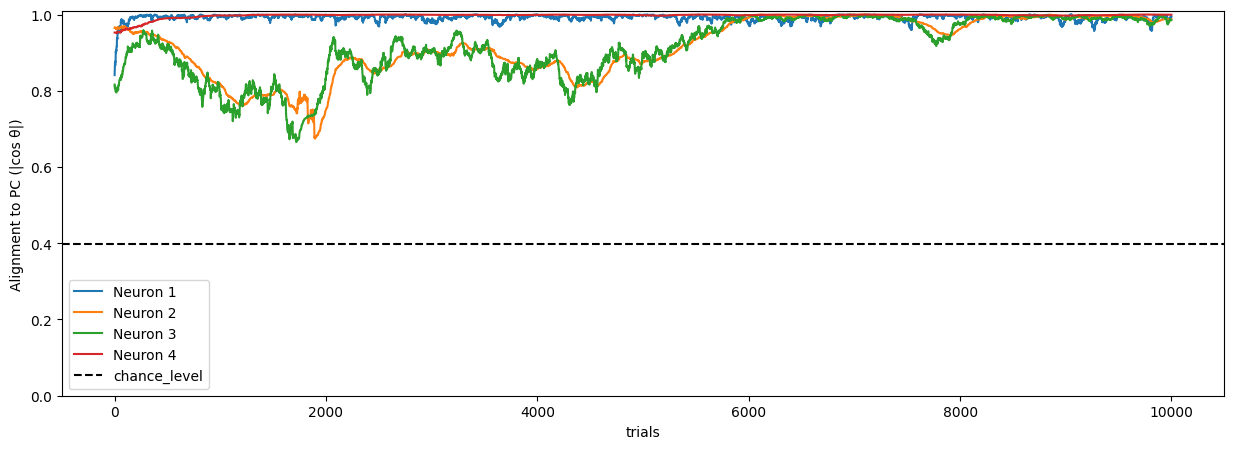

after second phase: model.W = [[-0.14326144 -0.04356439 -0.01923719 -0.03764349  0.2166767   0.01865872
  -0.03555088 -0.16304906  0.07439318 -0.00342325  0.1765562   0.04257712
  -0.0728147   0.07045303 -0.03978322  0.07687934  0.03775433 -0.04804775
   0.01918789  0.05839716 -0.1325118   0.27318171  0.02572991  0.06941798
  -0.17556812  0.10874098  0.21386084 -0.04821519  0.03095277  0.06022933
  -0.01506748  0.05273486 -0.05399549  0.07564208 -0.26711591 -0.06014899
   0.19683829  0.08986109 -0.27327638  0.21980473 -0.01281381  0.20785175
   0.01661078  0.03668647  0.06169341  0.03518748  0.12225271 -0.17297949
  -0.06147091  0.01679192 -0.04041928 -0.12351079  0.03056666 -0.01933041
   0.01316814  0.11734054 -0.01171361 -0.03221592  0.01902172  0.03461679
   0.41044072  0.00281239  0.00476048  0.06523324]
 [-0.12799701 -0.20000252  0.0781117   0.01189544  0.02380641  0.30969847
   0.23214054 -0.12714255  0.1945636  -0.00132155 -0.10995137  0.02344529
   0.16556957  0.12857498 -0.06

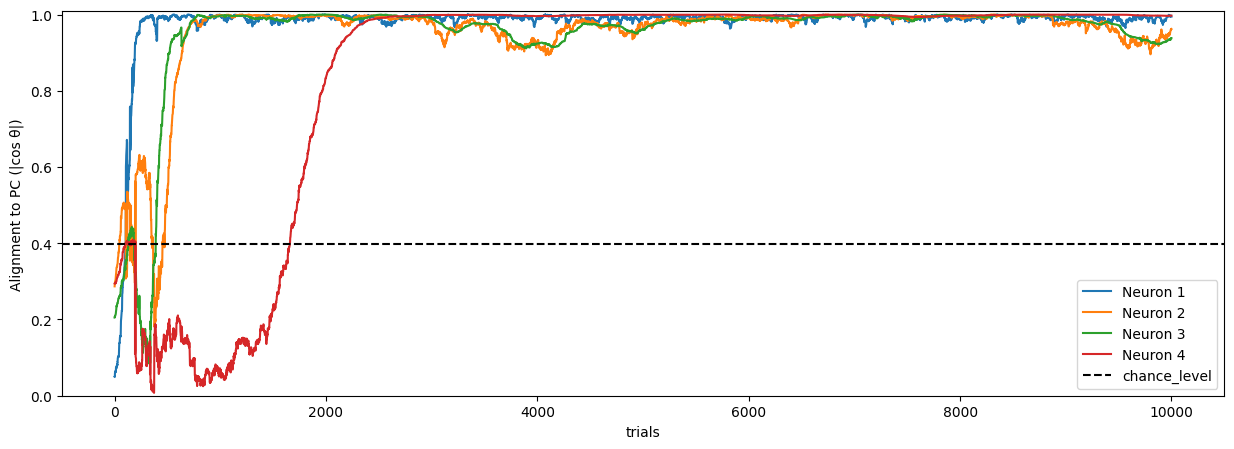

W after first phase: [[-1.12588588e-01 -8.48277544e-02 -9.81422944e-02 -8.83224496e-02
   1.14557995e-01  1.62592025e-01  1.57361943e-01 -1.50023013e-01
   5.67050455e-02  5.44267840e-02  1.65649539e-01  1.46594855e-02
   3.91208058e-02  2.08166981e-01 -6.53705321e-02 -2.42393422e-02
   1.68332541e-02 -3.42540970e-02 -2.71077791e-02  1.39727789e-01
  -5.81691583e-02  3.01476020e-01 -3.45184141e-02 -6.04246781e-02
  -1.43697066e-01  1.07011612e-01  1.34807176e-01  2.64407029e-02
   1.34393835e-01  3.13968580e-02 -6.48167615e-02  7.74364709e-02
  -5.25676108e-02  2.75735929e-02 -1.67415654e-01 -4.03666948e-02
   2.38811312e-01  6.82608832e-02 -2.14094599e-01  1.81494809e-01
  -5.93291219e-02  8.18874246e-02 -3.32644161e-02  1.71048875e-01
   7.57140863e-03  5.82486167e-03  1.01562318e-01 -1.42245545e-01
  -7.13973464e-02  1.29553364e-02 -1.10300122e-02 -1.15604933e-01
   2.31736316e-02  1.19609765e-01 -7.16507683e-02  5.43338753e-02
  -1.05317420e-01  5.67863415e-02  5.24280802e-02 -3.24

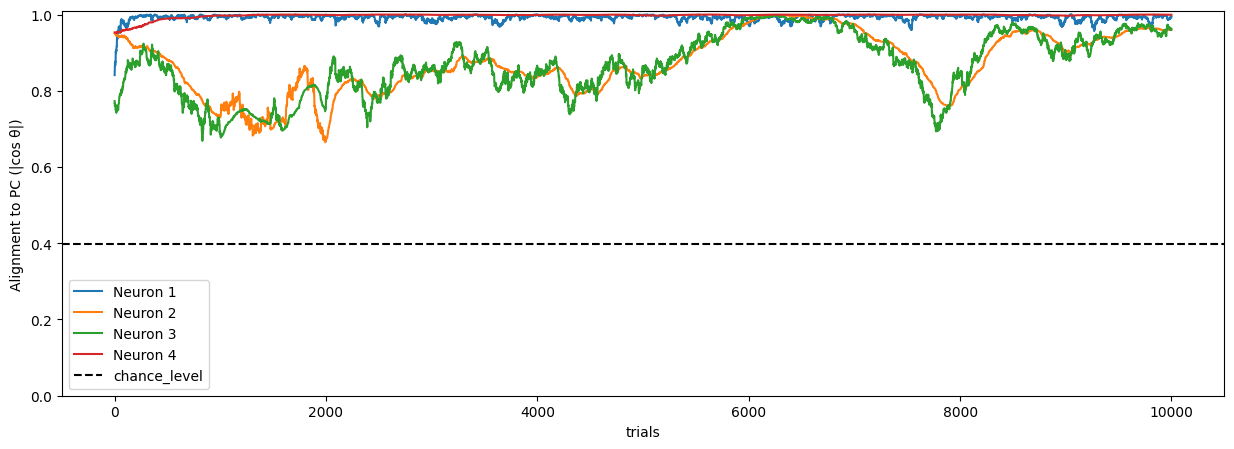

after second phase: model.W = [[-0.14326144 -0.04356439 -0.01923719 -0.03764349  0.2166767   0.01865872
  -0.03555088 -0.16304906  0.07439318 -0.00342325  0.1765562   0.04257712
  -0.0728147   0.07045303 -0.03978322  0.07687934  0.03775433 -0.04804775
   0.01918789  0.05839716 -0.1325118   0.27318171  0.02572991  0.06941798
  -0.17556812  0.10874098  0.21386084 -0.04821519  0.03095277  0.06022933
  -0.01506748  0.05273486 -0.05399549  0.07564208 -0.26711591 -0.06014899
   0.19683829  0.08986109 -0.27327638  0.21980473 -0.01281381  0.20785175
   0.01661078  0.03668647  0.06169341  0.03518748  0.12225271 -0.17297949
  -0.06147091  0.01679192 -0.04041928 -0.12351079  0.03056666 -0.01933041
   0.01316814  0.11734054 -0.01171361 -0.03221592  0.01902172  0.03461679
   0.41044072  0.00281239  0.00476048  0.06523324]
 [ 0.08207601  0.17820759  0.01665888  0.037705    0.03555212 -0.33407636
  -0.31143258  0.10436329 -0.1366928  -0.04063031  0.06582968  0.01304849
  -0.19182558 -0.20635194  0.06

<Figure size 640x480 with 0 Axes>

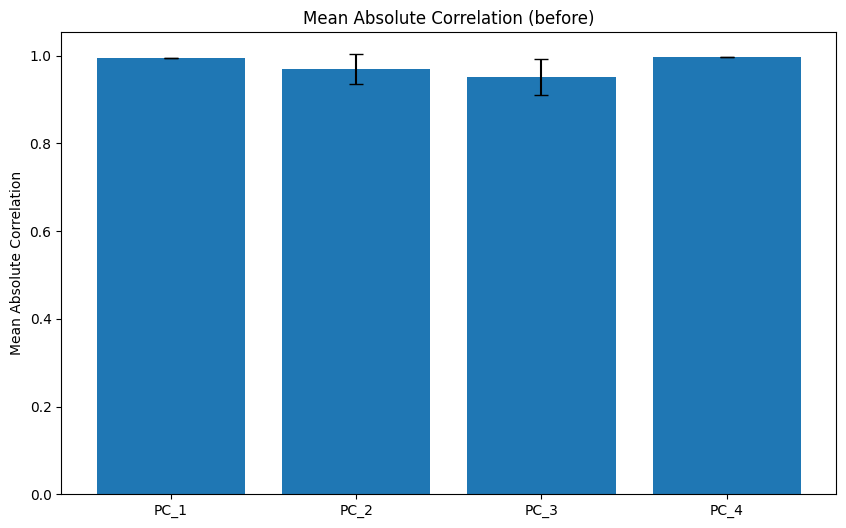

<Figure size 640x480 with 0 Axes>

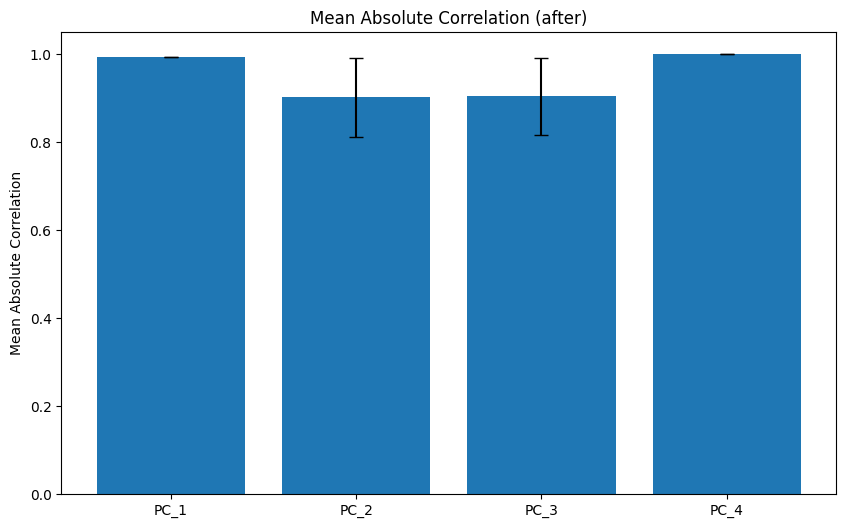

In [5]:
from hebbian.models import SangerNetwork
sanger_model = SangerNetwork(output_size=m, learning_rate=0.011, rng=None)

sanger_model_after = dict(learning_rate=0.01)

two_phase_training_testing(sanger_model, X_before, X_after, m, model_paras_after = sanger_model_after, runs = 10, graph = True)

### Leen's complete model

In [12]:
# runs = 10
model_paras = dict(
    input_dim=N, output_dim=m,
    eta_w=5e-3,          # base
    eta_v=5e-2,          # ~4x eta_w
    C=1.5,
    # ema_alpha=0.03,
    symmetrize_V=True,
    seed=None,
    noise_level=0.001,
    # settling_steps=10
)

model_paras_after = dict(
    eta_w=5e-3,
    eta_v=5e-2,
    C=1.5,
#     eta_w=6e-5,          # base
#     eta_v=5e-4,          # ~4x eta_w
)

run  1
X_before
step    0 | order = [3 2 1 0] | best|corr|= [0.078 0.144 0.101 0.257]
step 1000 | order = [3 2 1 0] | best|corr|= [0.24  0.9   0.957 0.997]
step 2000 | order = [3 2 1 0] | best|corr|= [0.661 0.978 0.976 0.995]
step 3000 | order = [3 2 1 0] | best|corr|= [0.948 0.979 0.981 0.999]
step 4000 | order = [3 2 1 0] | best|corr|= [0.991 0.994 0.999 0.977]
step 5000 | order = [3 2 1 0] | best|corr|= [0.983 0.979 0.995 0.996]
step 6000 | order = [3 2 1 0] | best|corr|= [0.996 0.999 0.978 0.999]
step 7000 | order = [3 2 1 0] | best|corr|= [0.978 0.99  0.981 0.975]
step 8000 | order = [3 2 1 0] | best|corr|= [0.99  0.995 0.992 0.995]
step 9000 | order = [3 2 1 0] | best|corr|= [0.999 0.996 0.991 0.993]
step 10000 | order = [3 2 1 0] | best|corr|= [0.997 0.977 0.972 0.967]


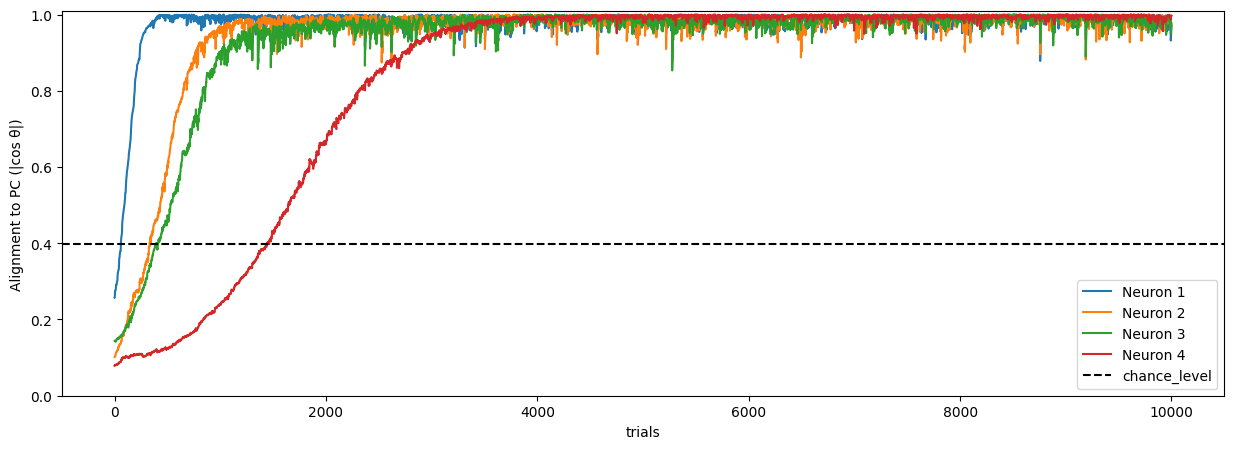

W after first phase: [[ 0.07321675  0.00285355 -0.12401563 -0.02463121 -0.07270168  0.04936973
   0.07736679 -0.02866025  0.05012076 -0.0407136  -0.08912023 -0.22282091
  -0.00333642 -0.0028919   0.04071012  0.07189033 -0.05902444  0.00898065
  -0.09369185 -0.16345183  0.04363285 -0.09008112  0.00433043  0.05511722
  -0.06160853  0.0315394   0.04089275  0.13186319 -0.07564302 -0.17374322
   0.10085923  0.06712942 -0.04490142  0.04777981  0.14055356  0.12834205
   0.11593283 -0.10157145  0.21255962  0.08860038  0.02954046 -0.00758288
  -0.06067532 -0.04519897  0.16422342 -0.15131938  0.20699966  0.0468283
  -0.14635116 -0.14588893 -0.03216046  0.15344085  0.04804684  0.18468694
  -0.02846371 -0.1067214   0.10306189 -0.1639326   0.19339923 -0.08905312
   0.07843328  0.20441212  0.12877851  0.10645619]
 [-0.14425888 -0.12054449  0.19666896  0.09223696  0.13838673  0.0758627
  -0.06050513 -0.11017047  0.19396755 -0.08320747 -0.1126833   0.06508027
   0.00452796 -0.09141218 -0.01550308  0.1

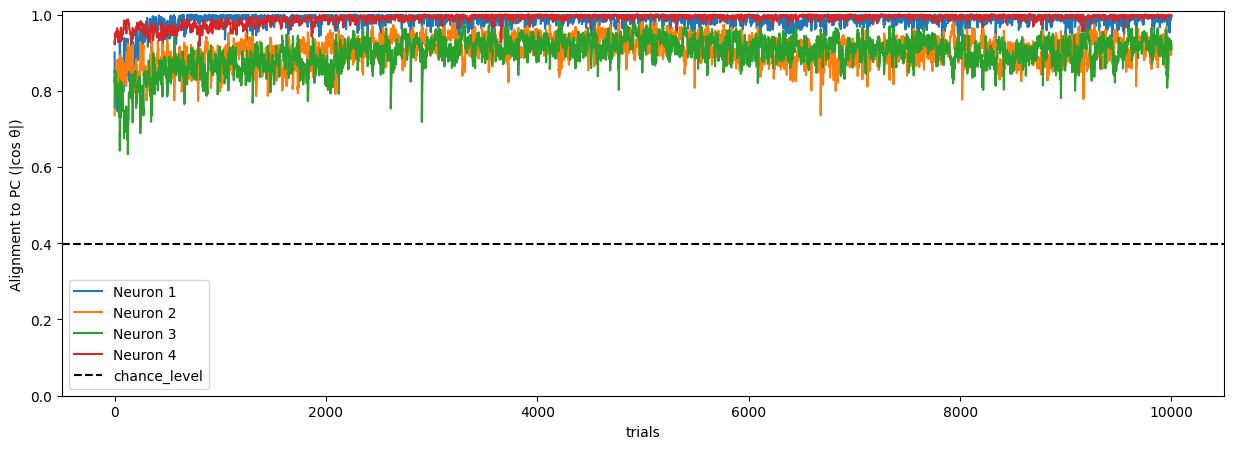

after second phase: model.W = [[ 6.51780767e-02  3.84756584e-02 -9.61501090e-02 -3.71542177e-03
  -1.86168952e-02 -4.48615391e-02 -3.48691466e-02 -3.04688134e-02
   4.46103217e-02 -6.84321061e-02 -6.77841593e-02 -2.12601896e-01
  -7.39586440e-02 -7.63410719e-02  5.70746099e-02  1.21440173e-01
  -4.00867541e-02 -9.57302132e-03 -5.90238660e-02 -2.13439978e-01
  -9.20415051e-03 -8.52962882e-02  2.62235680e-02  1.25281805e-01
  -6.45130911e-02  3.85455472e-02  8.62835284e-02  7.71259985e-02
  -1.24257184e-01 -1.53343739e-01  1.34479875e-01  6.74475254e-02
  -3.98951943e-02  7.08336567e-02  8.81896586e-02  1.27740644e-01
   9.94984871e-02 -8.54260584e-02  1.80972249e-01  1.05535969e-01
   5.26737202e-02  6.41253688e-02 -2.93550387e-02 -1.13728065e-01
   2.06090894e-01 -1.18973621e-01  2.38372056e-01  2.62905699e-02
  -1.29958726e-01 -1.45897910e-01 -6.41216530e-02  1.50165677e-01
   4.37105013e-02  1.19979432e-01  2.15719720e-02 -6.65195508e-02
   1.40915234e-01 -2.14128494e-01  1.72679330e

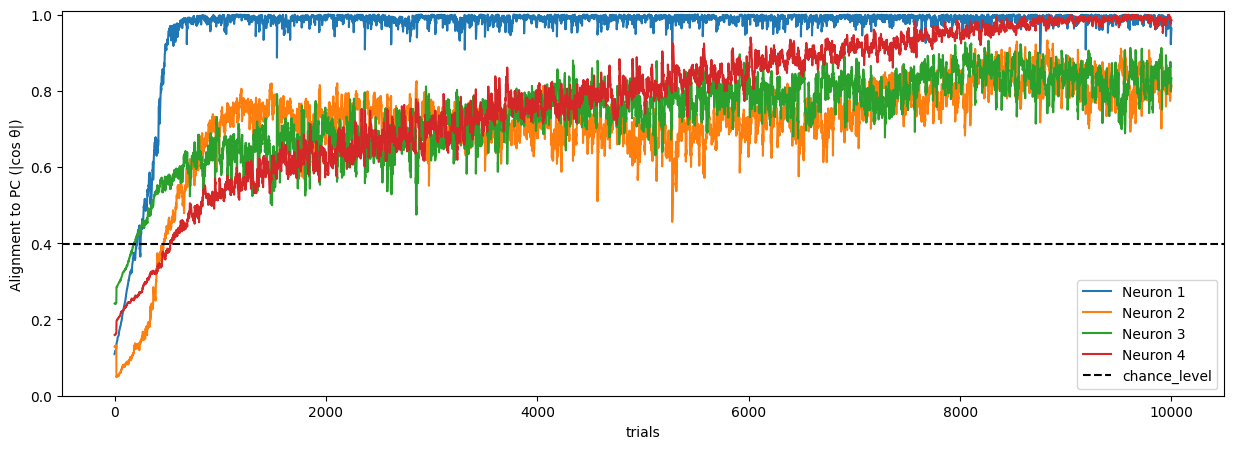

W after first phase: [[ 0.06196592 -0.01432437 -0.1097791  -0.01981468 -0.07144624  0.07320649
   0.092616   -0.03619977  0.0668001  -0.04198867 -0.1030757  -0.21559892
   0.01132075  0.00269087  0.0358081   0.07397832 -0.06716625  0.02102164
  -0.10500095 -0.15089378  0.05819045 -0.10607207  0.0141511   0.05045249
  -0.07835338  0.02609506  0.03765991  0.14874111 -0.07834451 -0.17753248
   0.0901031   0.05306236 -0.0516324   0.04976804  0.13728618  0.11567797
   0.11258526 -0.10499391  0.20809237  0.09378721  0.02939291 -0.01335831
  -0.06665032 -0.04333054  0.14732067 -0.16873697  0.18354289  0.04926134
  -0.15846802 -0.14196397 -0.01343651  0.14918272  0.05701027  0.17656502
  -0.03603065 -0.11315955  0.11225839 -0.15684469  0.19605174 -0.09935454
   0.05029787  0.201872    0.12437193  0.1234867 ]
 [-0.12933935 -0.05598148  0.18166904  0.09422296  0.18371348 -0.04775471
  -0.17909601 -0.10095201  0.15406741 -0.10069681 -0.05701127  0.05598581
  -0.08455453 -0.15481347  0.00643679  0

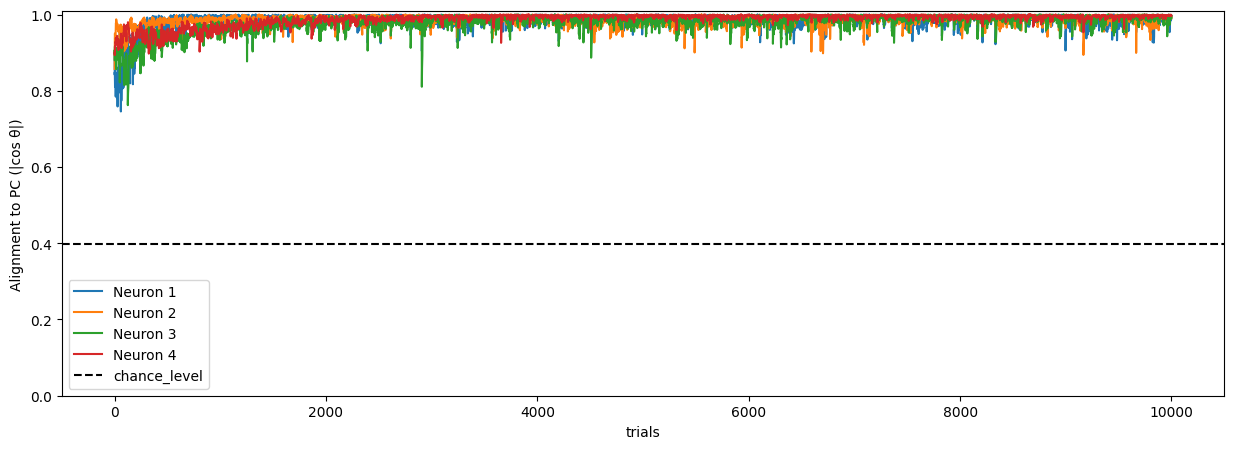

after second phase: model.W = [[ 6.56103448e-02  3.91096474e-02 -9.64392999e-02 -3.77135804e-03
  -1.87354255e-02 -4.58125285e-02 -3.55511749e-02 -3.00553568e-02
   4.39812857e-02 -6.84146148e-02 -6.74444531e-02 -2.12710586e-01
  -7.44585411e-02 -7.67155654e-02  5.72699050e-02  1.21342263e-01
  -3.98053352e-02 -9.93192056e-03 -5.85759258e-02 -2.13873994e-01
  -9.63643769e-03 -8.50226116e-02  2.59332713e-02  1.25446312e-01
  -6.37861249e-02  3.85936464e-02  8.62190855e-02  7.64772853e-02
  -1.24247311e-01 -1.53144831e-01  1.34823246e-01  6.77833866e-02
  -3.95961584e-02  7.07065926e-02  8.83831479e-02  1.28110174e-01
   9.92973135e-02 -8.53217684e-02  1.81201937e-01  1.05126612e-01
   5.27148346e-02  6.42228533e-02 -2.90947029e-02 -1.13919215e-01
   2.06519565e-01 -1.18323835e-01  2.38894000e-01  2.63279604e-02
  -1.29403594e-01 -1.45944903e-01 -6.46922256e-02  1.50322613e-01
   4.33668146e-02  1.20017159e-01  2.18985847e-02 -6.63039832e-02
   1.40650384e-01 -2.14301545e-01  1.72421423e

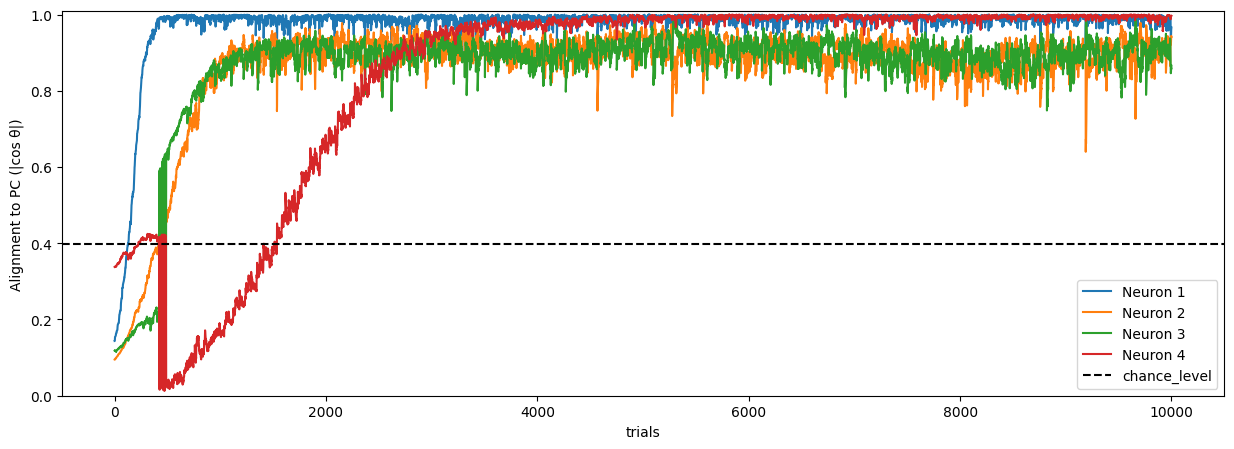

W after first phase: [[-0.12621206 -0.08930124 -0.07983552 -0.07717335  0.13764284  0.15321361
   0.13236779 -0.16366691  0.07640292  0.03961007  0.15802775  0.01412133
   0.02457955  0.1860105  -0.06239651  0.00347046  0.0132124  -0.02953665
  -0.0301993   0.12456278 -0.06421863  0.28705942 -0.01477161 -0.03269053
  -0.16957573  0.10821282  0.1563416   0.02898237  0.10842144  0.0266425
  -0.05705641  0.06789549 -0.06135666  0.04321151 -0.18900515 -0.04756819
   0.2396034   0.06705156 -0.22458065  0.20338052 -0.04879715  0.10828474
  -0.03023104  0.14382023  0.01748233 -0.0075877   0.1041944  -0.14873217
  -0.08735438  0.00885322 -0.00691511 -0.11495027  0.0342399   0.09573465
  -0.06101227  0.05980732 -0.07486741  0.03391951  0.05863341 -0.00666434
   0.40456553  0.00717453  0.02700334  0.19273937]
 [ 0.0695331  -0.03807142 -0.10396838 -0.06792679 -0.18042366  0.17967383
   0.26518826  0.06192631 -0.06409544  0.09475495 -0.02115955 -0.0162301
   0.1671145   0.18631129 -0.03327424 -0.1

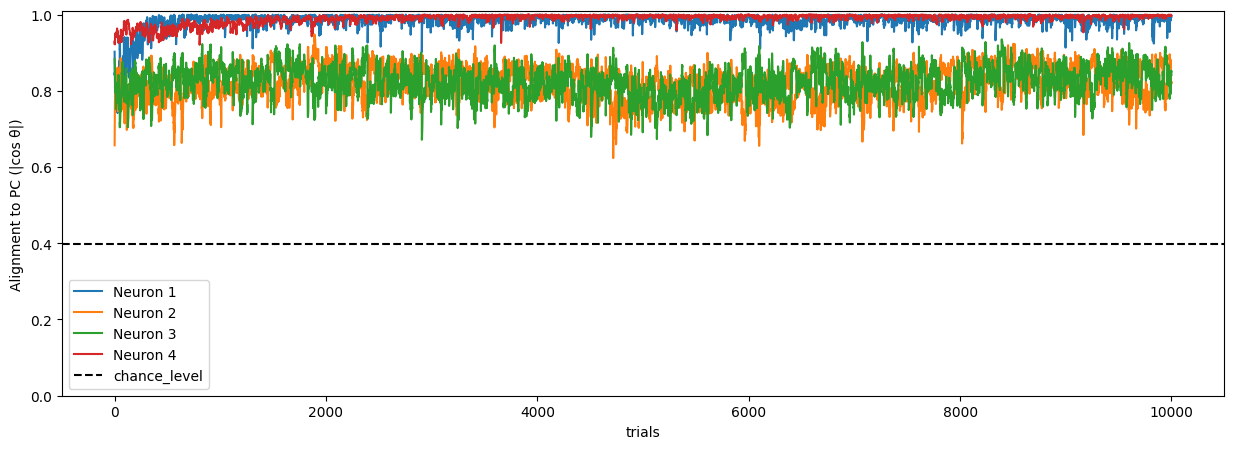

after second phase: model.W = [[-0.13026564 -0.02373809 -0.02210552 -0.03648802  0.21266461 -0.01334226
  -0.0606486  -0.14739408  0.05434777 -0.00344528  0.1843419   0.04425333
  -0.08803364  0.0548023  -0.0336285   0.07338706  0.04666422 -0.0575963
   0.03463708  0.0464021  -0.14453818  0.27590397  0.01844833  0.0745939
  -0.15056667  0.10694532  0.20829575 -0.07023388  0.02952686  0.06907505
  -0.00603282  0.05882781 -0.04338775  0.07052028 -0.26129686 -0.05176771
   0.18299843  0.0935685  -0.26685624  0.2022832  -0.0108172   0.20927763
   0.02620037  0.02799512  0.07006688  0.05679343  0.13003825 -0.16981605
  -0.04093048  0.01844718 -0.05557785 -0.11990894  0.01932401 -0.02556413
   0.02488696  0.12473741 -0.01876405 -0.03499061  0.00614591  0.04772409
   0.41194566 -0.00292214  0.00217384  0.0351687 ]
 [ 0.02604425 -0.06467114 -0.16748188 -0.10380423 -0.11056852  0.22676566
   0.30260167 -0.02708992 -0.01498177  0.09000954  0.03986783 -0.07030527
   0.14654729  0.24386009 -0.0444

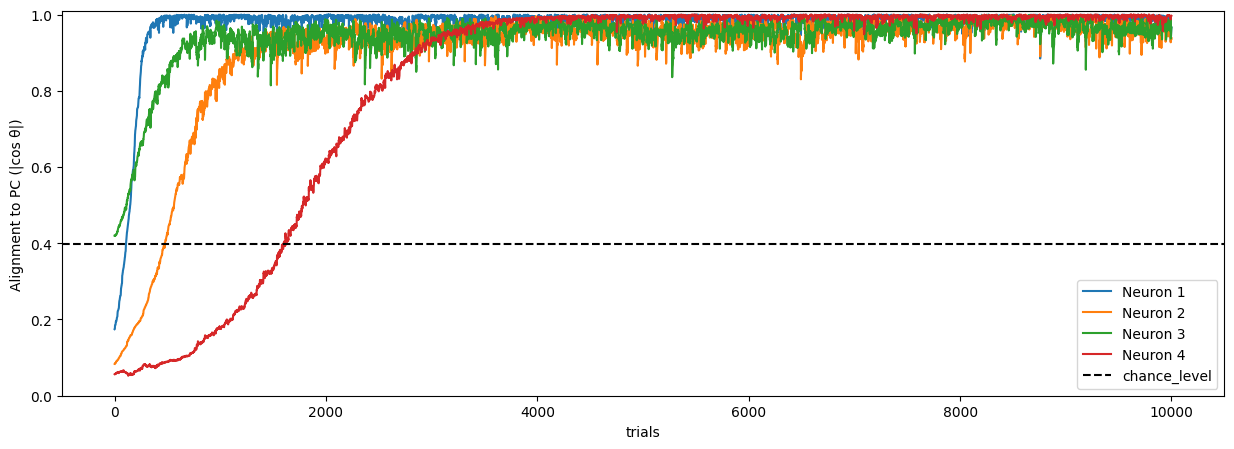

W after first phase: [[ 0.02256433  0.13121996 -0.01961408  0.01336609  0.11136159 -0.26482649
  -0.26690983  0.00685938 -0.06425325 -0.05129781  0.10514631 -0.02820233
  -0.19881052 -0.15271497  0.05025283  0.09975112  0.0659467  -0.08707569
   0.10260977 -0.15448218 -0.1665564   0.09236188  0.00476551  0.16288853
   0.03701411  0.04951851  0.12440163 -0.16159719 -0.08464986  0.0418604
   0.11475276  0.06934853  0.02611778  0.0479372  -0.09837413  0.05648928
   0.01513824  0.04288459 -0.04795018  0.04295625  0.04555095  0.17824976
   0.07806608 -0.13651789  0.16934427  0.11847588  0.1866958  -0.06144467
   0.05781752 -0.02891922 -0.14237591  0.01377308 -0.03590386 -0.07159441
   0.12240604  0.102356    0.04333811 -0.14245965 -0.02757238  0.09121238
   0.22238334  0.03834364  0.01537894 -0.20717113]
 [ 0.12402797  0.08660684  0.08234419  0.07800868 -0.13672109 -0.14981167
  -0.13056772  0.16215915 -0.07362646 -0.03992517 -0.15979293 -0.01264427
  -0.02267807 -0.18533407  0.06157778 -0.

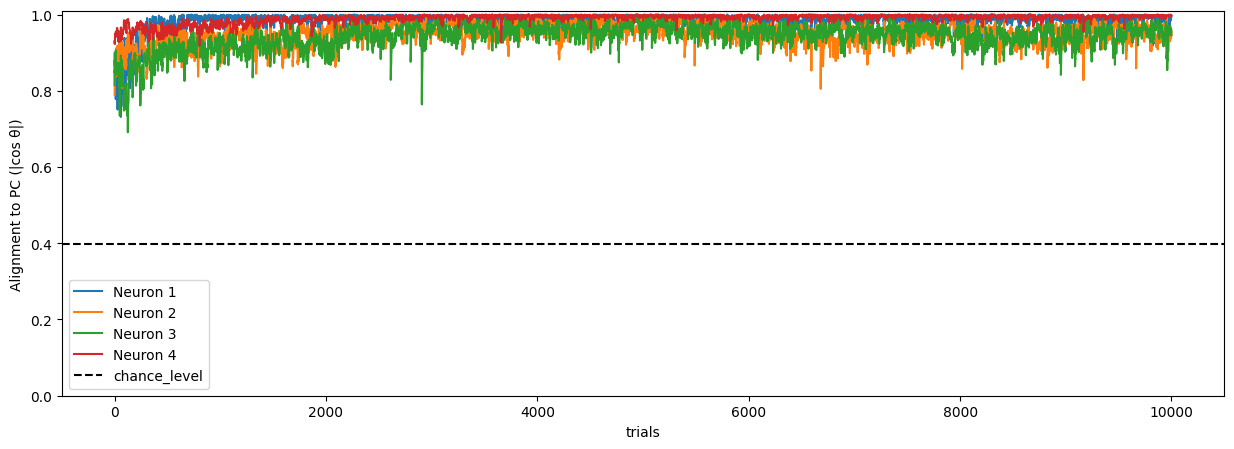

after second phase: model.W = [[ 0.07492013  0.16339825  0.03022884  0.0417696   0.03018776 -0.31128349
  -0.29378767  0.10325847 -0.12652453 -0.03853412  0.05208917  0.02380006
  -0.17400649 -0.19883637  0.0607565   0.04082771  0.0717809  -0.07207742
   0.13280878 -0.13986619 -0.12474635 -0.01137365 -0.01108649  0.11847362
   0.15436967 -0.01434616  0.00687158 -0.19422959 -0.07970797  0.07349333
   0.09638607  0.02476648  0.0722931  -0.0052712  -0.01321642  0.04873481
  -0.12628992  0.03415628  0.01889997 -0.10033312  0.04493902  0.08430238
   0.09600458 -0.14891805  0.09323203  0.16197583  0.06610518  0.00853316
   0.14558448  0.01035486 -0.12147878  0.02669767 -0.07182956 -0.12876043
   0.13401911  0.08518116  0.01546921 -0.07892596 -0.10633219  0.11091387
  -0.00147166 -0.03094509 -0.03004107 -0.29316814]
 [ 0.13112126  0.024448    0.02233876  0.03676527 -0.21357177  0.01229723
   0.05993707  0.148532   -0.0552029   0.00344702 -0.18485733 -0.04413839
   0.08789658 -0.05563203  0.03

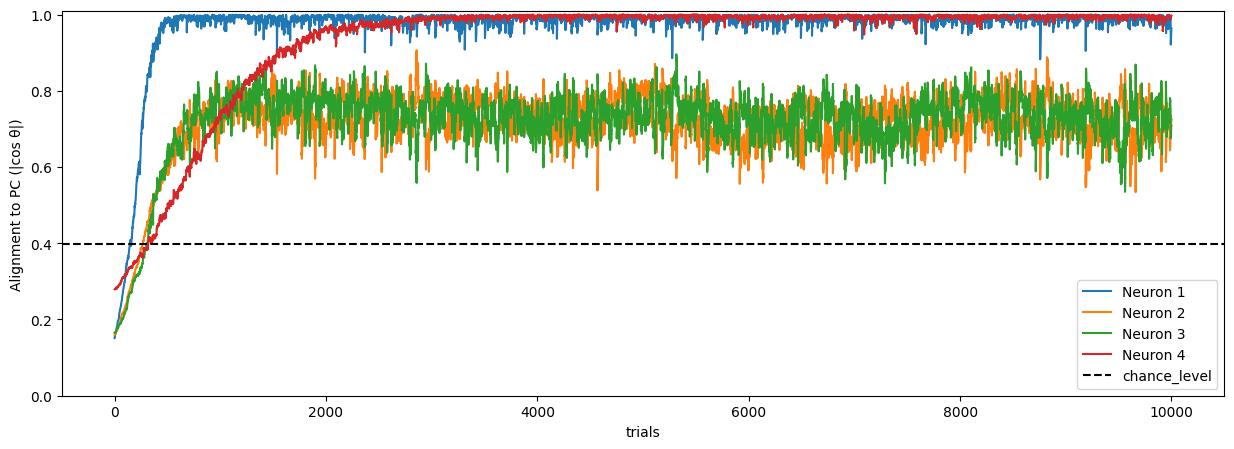

W after first phase: [[-0.12523594 -0.08887018 -0.08037249 -0.07734655  0.13628009  0.15314564
   0.13294987 -0.16269618  0.07553885  0.03995556  0.15765344  0.01381446
   0.02503283  0.18620078 -0.06225355  0.00256688  0.01321164 -0.02958209
  -0.03012719  0.12450331 -0.0637193   0.28650507 -0.0154099  -0.03350808
  -0.16820397  0.10785298  0.15511534  0.02899051  0.10889444  0.02649512
  -0.05703082  0.06808485 -0.06091104  0.04257815 -0.18744354 -0.04700643
   0.23894425  0.06674088 -0.22320768  0.20206186 -0.04897634  0.10697471
  -0.03032761  0.14426859  0.01726391 -0.00730345  0.10400155 -0.1479544
  -0.08670742  0.0087863  -0.00705737 -0.11440684  0.03380796  0.09650528
  -0.06124045  0.05927123 -0.07556507  0.03442119  0.0584765  -0.0066494
   0.40345408  0.00702656  0.02709123  0.19255947]
 [ 0.11472639  0.02875329 -0.16292878 -0.08914649 -0.18850263  0.08990885
   0.21138317  0.09257785 -0.13190708  0.10265449  0.03544037 -0.04389606
   0.11309374  0.16995472 -0.01528745 -0.1

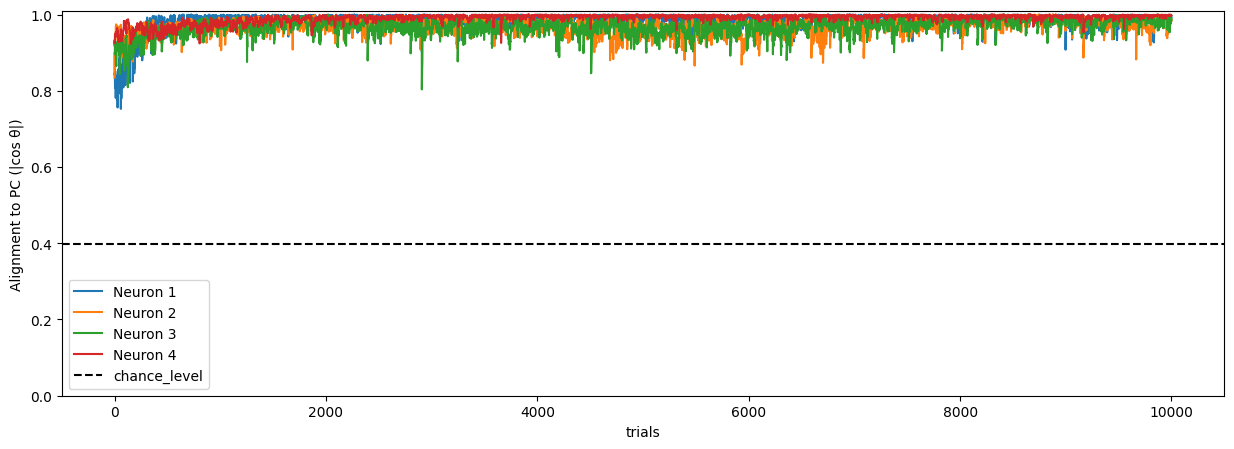

after second phase: model.W = [[-0.13142916 -0.02488675 -0.02198712 -0.03663088  0.21367173 -0.01171805
  -0.0596091  -0.14878878  0.05569512 -0.003534    0.18448838  0.04423997
  -0.08758929  0.05571718 -0.03404158  0.07396419  0.04631472 -0.05726098
   0.03389202  0.04707454 -0.14440078  0.27659674  0.01898442  0.0747108
  -0.15253142  0.10741597  0.2093999  -0.06925103  0.02956324  0.06876275
  -0.00646515  0.05868273 -0.04414869  0.07111316 -0.26253517 -0.05237657
   0.18438824  0.09364949 -0.26807318  0.20401708 -0.01090353  0.21002077
   0.02577474  0.0284153   0.0699556   0.05573307  0.13014172 -0.17056909
  -0.04227315  0.01835694 -0.05495445 -0.12045156  0.02004856 -0.02536618
   0.02438794  0.12475578 -0.01828682 -0.03511465  0.00693765  0.04714715
   0.41326181 -0.00251515  0.00235763  0.03687808]
 [ 0.08683677  0.01846551 -0.21505488 -0.11758361 -0.13498167  0.11008063
   0.22802881  0.03067604 -0.10495464  0.09997062  0.08999186 -0.08401481
   0.08896904  0.20864911 -0.021

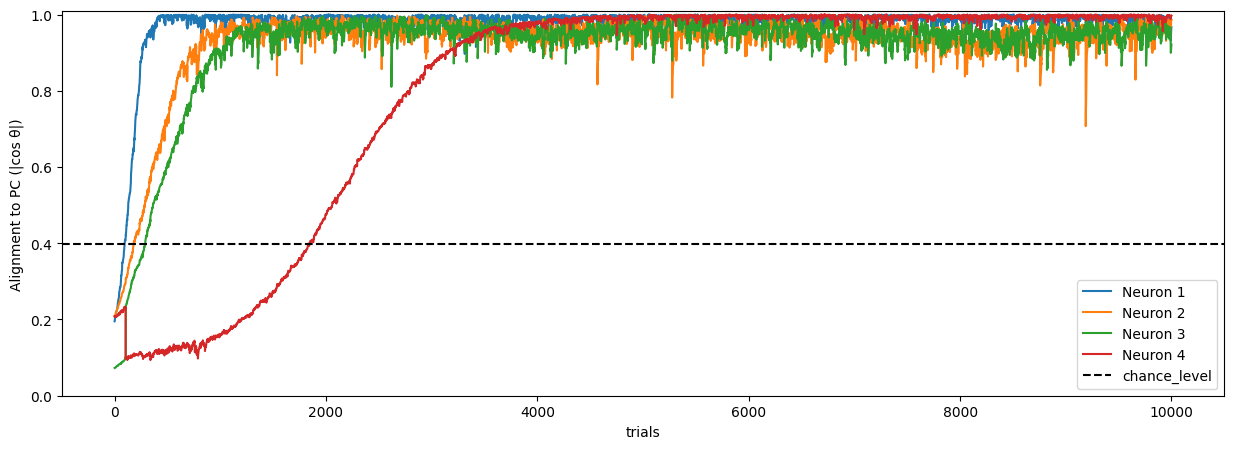

W after first phase: [[ 0.07353466  0.00265332 -0.12470422 -0.02501602 -0.07342367  0.05022364
   0.07858235 -0.02856802  0.04998538 -0.04040634 -0.08921926 -0.22324839
  -0.00268367 -0.00201693  0.04060981  0.07132208 -0.05917627  0.00900886
  -0.09402034 -0.16317614  0.04409214 -0.08990786  0.0039401   0.05439232
  -0.06139483  0.03157647  0.04044674  0.13238532 -0.07504963 -0.17408987
   0.10067727  0.06742012 -0.04491999  0.0475136   0.14132917  0.12864259
   0.11635902 -0.10179996  0.21315063  0.08845962  0.0292889  -0.00835921
  -0.06102391 -0.04442003  0.16414604 -0.15158647  0.20719582  0.04708274
  -0.14650894 -0.14607979 -0.03208536  0.15366243  0.04802536  0.18582024
  -0.0289765  -0.10720908  0.10254828 -0.16358601  0.19382602 -0.0893299
   0.07861976  0.20459082  0.12906438  0.10734693]
 [ 0.04760795 -0.0643945  -0.0749801  -0.05611609 -0.16908423  0.20944388
   0.27614364  0.04617324 -0.03269053  0.08715318 -0.04402339 -0.00442617
   0.18228561  0.18495344 -0.03926369 -0.

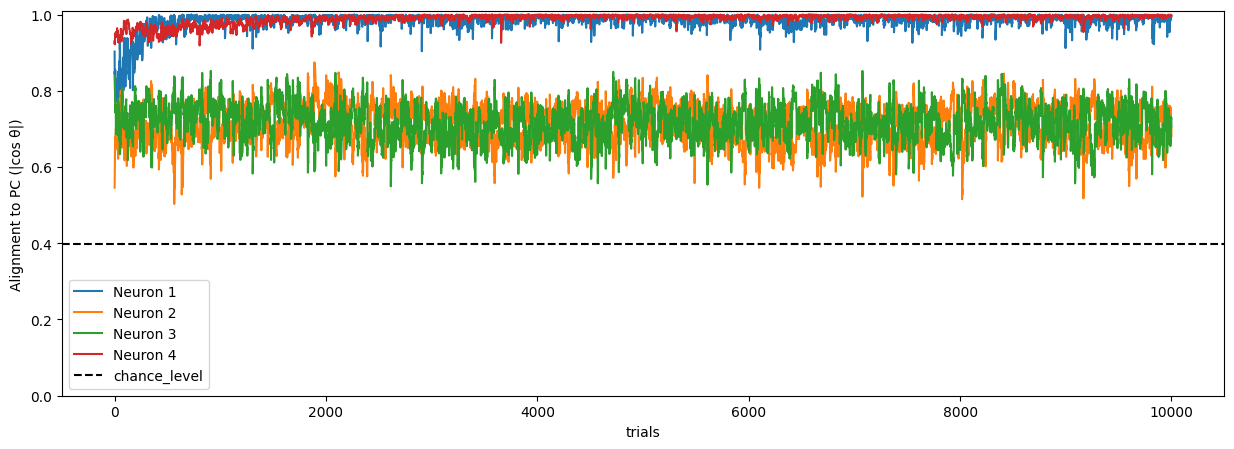

after second phase: model.W = [[ 0.06531538  0.03868475 -0.09667523 -0.00400492 -0.01864499 -0.04497378
  -0.03472761 -0.03045698  0.04426673 -0.06823172 -0.06726103 -0.21272071
  -0.0740547  -0.07598631  0.057049    0.12118004 -0.03990116 -0.00986288
  -0.05885205 -0.21336566 -0.00949252 -0.08449715  0.02586563  0.12508585
  -0.06424913  0.03878576  0.086382    0.07686376 -0.12384268 -0.15321411
   0.13452771  0.0678739  -0.03979461  0.07073165  0.08817283  0.12796418
   0.09989932 -0.0852699   0.18083762  0.10555639  0.05252014  0.06415465
  -0.02932504 -0.11332949  0.20633806 -0.11858141  0.23892107  0.02609634
  -0.12974934 -0.1459304  -0.06449361  0.15008362  0.04351399  0.12047363
   0.0215241  -0.06637821  0.14040031 -0.21402265  0.17267995 -0.0592202
   0.11092438  0.20810238  0.12036146  0.022788  ]
 [-0.00481599 -0.10008262 -0.13281753 -0.08971915 -0.09124271  0.26687217
   0.31705995 -0.05294868  0.02959322  0.07860358  0.01238206 -0.05932991
   0.16383607  0.2432178  -0.052

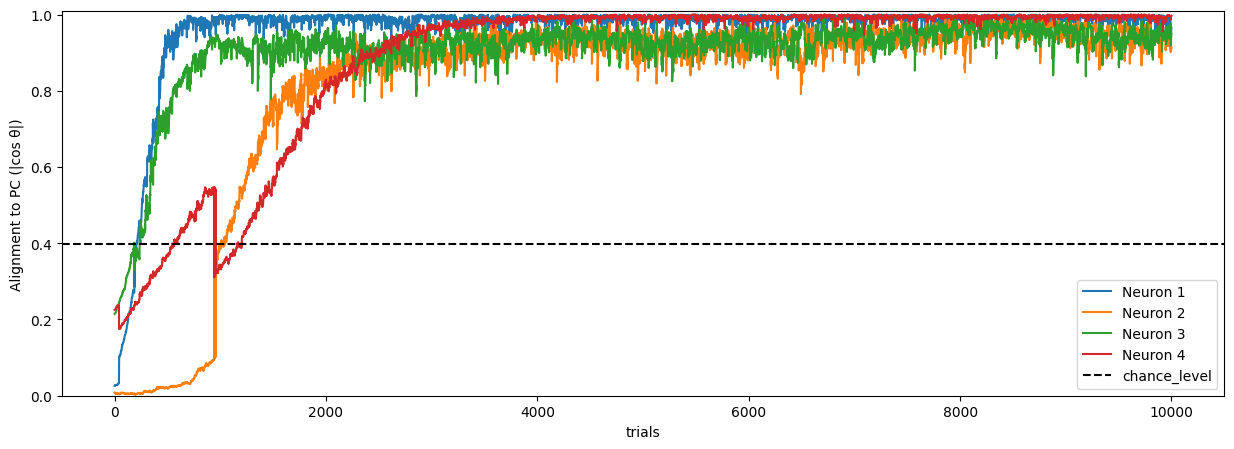

W after first phase: [[-0.14140816 -0.09450855  0.19512546  0.09567856  0.16284508  0.02174763
  -0.11611878 -0.10914938  0.18133509 -0.09358819 -0.09059654  0.06236935
  -0.03596573 -0.12286279 -0.00587453  0.17333445 -0.04504404  0.07607685
  -0.04741021 -0.02255158  0.01153057 -0.14409757  0.1642026   0.15065583
  -0.21765896 -0.02067575  0.11582943  0.05908525 -0.16584114 -0.01610209
  -0.00834566 -0.1284394  -0.0738754   0.0991193  -0.17183338 -0.11649337
  -0.03175174 -0.00485905 -0.11705003  0.14189906  0.06270531  0.14611918
   0.00700617 -0.16185327 -0.03056198 -0.12781404 -0.11146564 -0.03758664
  -0.12303476  0.0136554   0.10488656 -0.03662437  0.09701412 -0.21766575
   0.04455644  0.02715373  0.21452724 -0.09160467  0.01613166 -0.04672249
  -0.15382956  0.02473031 -0.04204272 -0.00629658]
 [-0.03355944 -0.13927817  0.03477668 -0.00594055 -0.09936992  0.26795273
   0.2592856  -0.0154808   0.07893671  0.04408043 -0.11310302  0.03267782
   0.1969811   0.14374866 -0.05084181 -0

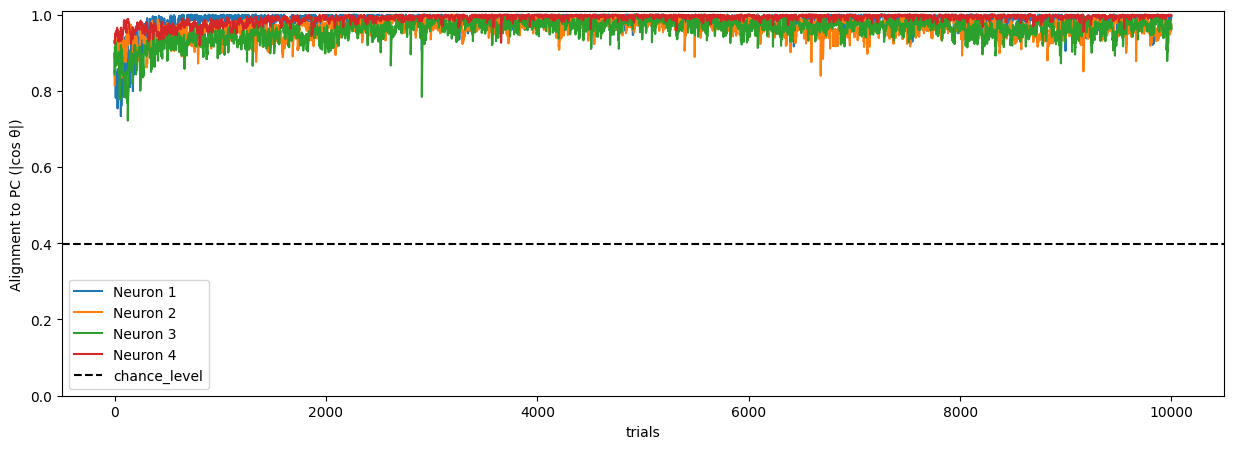

after second phase: model.W = [[-1.23955131e-01 -8.15311644e-02  2.24524516e-01  1.12963585e-01
   1.37527037e-01 -4.08770228e-03 -1.39986386e-01 -7.26235141e-02
   1.62118794e-01 -9.46816077e-02 -1.16756447e-01  8.44214809e-02
  -3.24096413e-02 -1.53483234e-01  3.75223895e-04  1.59983137e-01
  -4.37675272e-02  8.42142699e-02 -3.50547354e-02 -2.37925041e-02
   2.64657190e-02 -1.95516870e-01  1.65716613e-01  1.44017445e-01
  -1.77046434e-01 -4.78988226e-02  7.41528776e-02  4.51640579e-02
  -1.75399270e-01 -4.32082510e-03 -1.22631131e-02 -1.51602353e-01
  -5.72734558e-02  8.27784592e-02 -1.43923314e-01 -1.22423022e-01
  -9.32824959e-02 -9.16283567e-03 -9.20182553e-02  8.86793254e-02
   6.72542966e-02  1.17102536e-01  1.65157603e-02 -1.79807725e-01
  -5.85178269e-02 -1.14045705e-01 -1.61910133e-01 -9.85699462e-03
  -9.12273956e-02  2.87281515e-02  1.14970155e-01 -3.02960575e-02
   8.58429727e-02 -2.53066288e-01  5.48494166e-02  2.23213208e-02
   2.15740648e-01 -7.45688392e-02 -1.56287236e

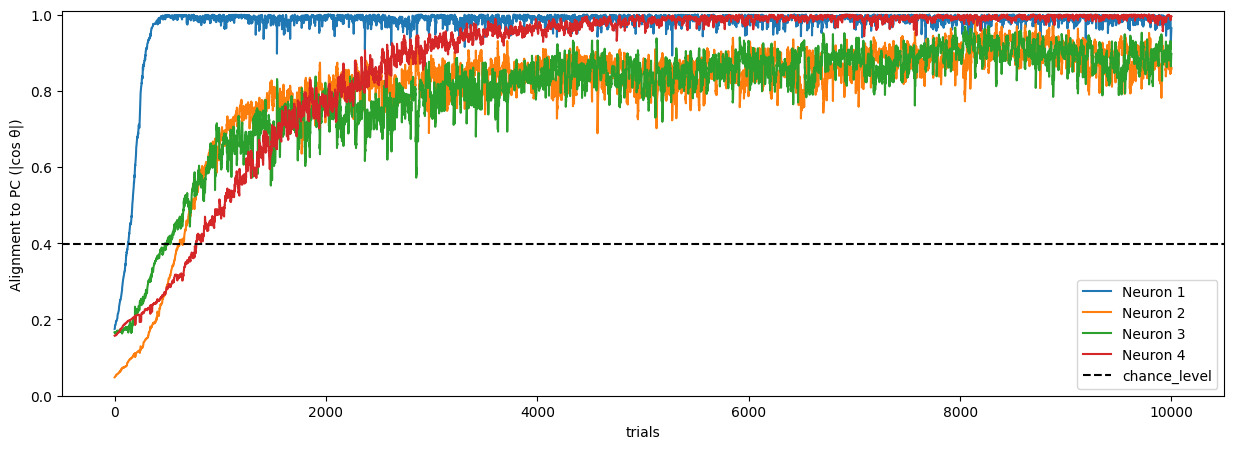

W after first phase: [[-1.24089783e-01 -8.72502004e-02 -8.18686766e-02 -7.78466823e-02
   1.36059021e-01  1.50977542e-01  1.31640935e-01 -1.62002419e-01
   7.39926117e-02  4.00600707e-02  1.58895954e-01  1.29134345e-02
   2.36770727e-02  1.85719629e-01 -6.17609747e-02  2.39827218e-03
   1.39239179e-02 -3.07146252e-02 -2.91537954e-02  1.23190591e-01
  -6.50368816e-02  2.87957026e-01 -1.63606293e-02 -3.30604723e-02
  -1.66658279e-01  1.08400133e-01  1.55432746e-01  2.75327944e-02
   1.09120395e-01  2.66867314e-02 -5.59346861e-02  6.94934971e-02
  -6.03114109e-02  4.24147943e-02 -1.86969355e-01 -4.56778111e-02
   2.39387774e-01  6.69652284e-02 -2.22568001e-01  2.01638659e-01
  -4.89529880e-02  1.07472583e-01 -2.98332683e-02  1.44098903e-01
   1.90026253e-02 -5.79715984e-03  1.06416317e-01 -1.48133007e-01
  -8.56935048e-02  8.27882886e-03 -8.85793969e-03 -1.13858683e-01
   3.29978585e-02  9.74991767e-02 -6.05779838e-02  5.97640270e-02
  -7.63783397e-02  3.36303393e-02  5.84152049e-02 -5.76

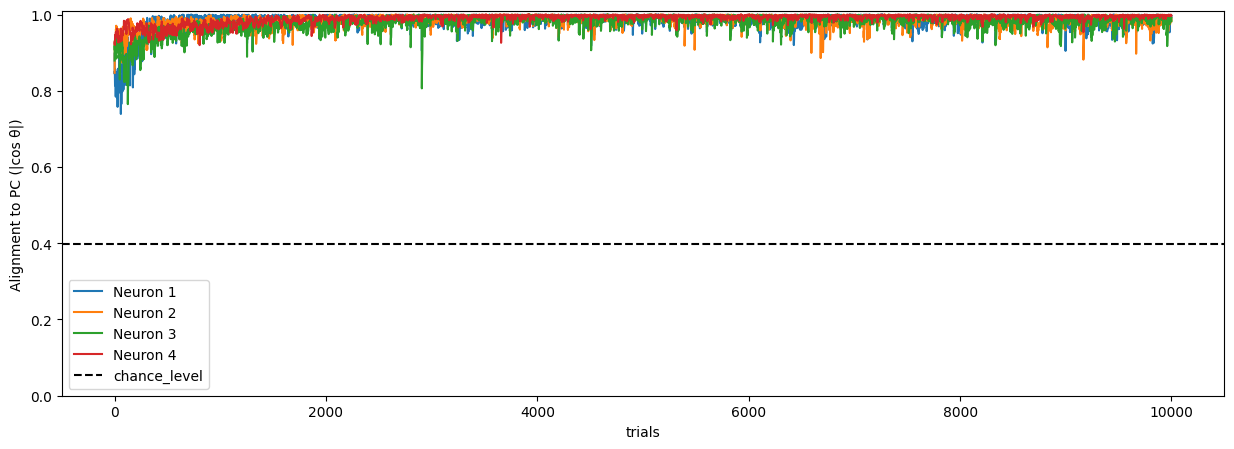

after second phase: model.W = [[-0.13145537 -0.02484072 -0.02220536 -0.03675484  0.21378701 -0.01174016
  -0.05957667 -0.14889849  0.05564435 -0.00348604  0.18474983  0.04416321
  -0.08767761  0.05586879 -0.03406136  0.0739559   0.04638476 -0.05738673
   0.03393726  0.04708143 -0.14457438  0.27700857  0.01888749  0.07471641
  -0.15257635  0.10757506  0.20958768 -0.0693358   0.02969055  0.06879485
  -0.0064248   0.0588767  -0.04416311  0.07114546 -0.26267718 -0.05230365
   0.18467889  0.09373032 -0.26823374  0.20419366 -0.01095047  0.21017087
   0.02578116  0.0285476   0.0701307   0.0558435   0.13046629 -0.17073274
  -0.04228545  0.01831358 -0.05511624 -0.1205126   0.02001745 -0.02516948
   0.02437856  0.12485093 -0.01842793 -0.03515583  0.0070051   0.04720921
   0.41391417 -0.00245889  0.00244023  0.03695911]
 [-0.06551159 -0.03899654  0.09625401  0.00368455  0.01868056  0.04571452
   0.03555788  0.03010865 -0.04413336  0.06847194  0.06758961  0.21264023
   0.07440514  0.07678419 -0.05

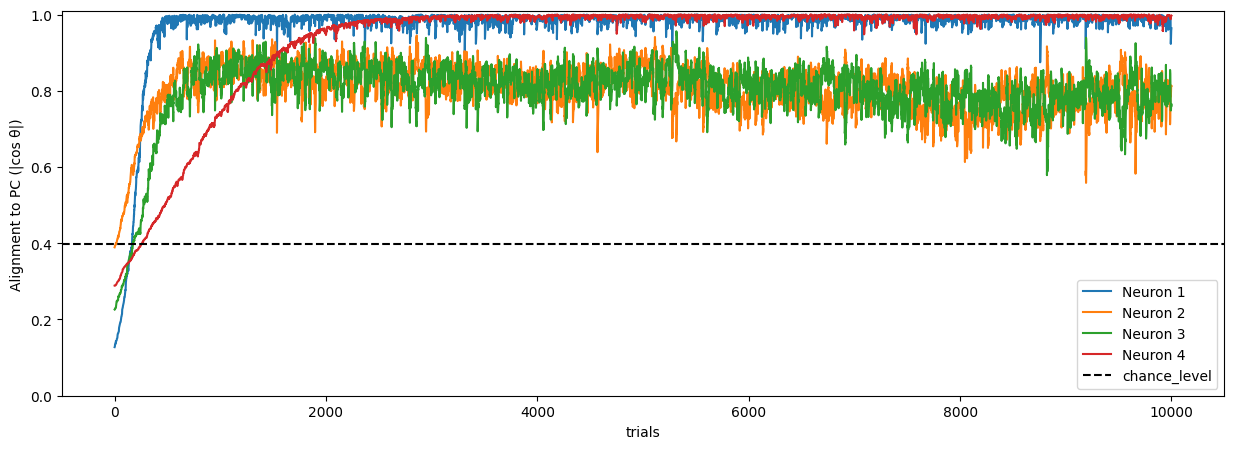

W after first phase: [[ 0.072857    0.00261674 -0.12399581 -0.02459852 -0.07215241  0.04953811
   0.07724904 -0.02923507  0.050688   -0.04098993 -0.08913888 -0.22314701
  -0.00355753 -0.00297615  0.04071218  0.07252125 -0.05916673  0.00902999
  -0.09393573 -0.16376028  0.04348971 -0.08999141  0.00469098  0.05566311
  -0.06247304  0.03179488  0.04161449  0.13215988 -0.07605412 -0.17404628
   0.10105166  0.06716615 -0.04522947  0.04820253  0.14005664  0.12832534
   0.11654499 -0.10164528  0.2123215   0.0894871   0.02968968 -0.00692154
  -0.0607664  -0.0455292   0.16468716 -0.15182342  0.20754658  0.04653239
  -0.14701762 -0.14616281 -0.03215146  0.15350698  0.04839012  0.18470786
  -0.02841974 -0.1066801   0.10367125 -0.16453628  0.19391972 -0.08927959
   0.07915792  0.20493033  0.12902375  0.10680601]
 [ 0.1073887   0.16826463 -0.13916612 -0.04998488 -0.01060942 -0.23256708
  -0.1466997   0.07531157 -0.16940325  0.01827679  0.14654611 -0.05953628
  -0.14083992 -0.04676407  0.04434366 -0

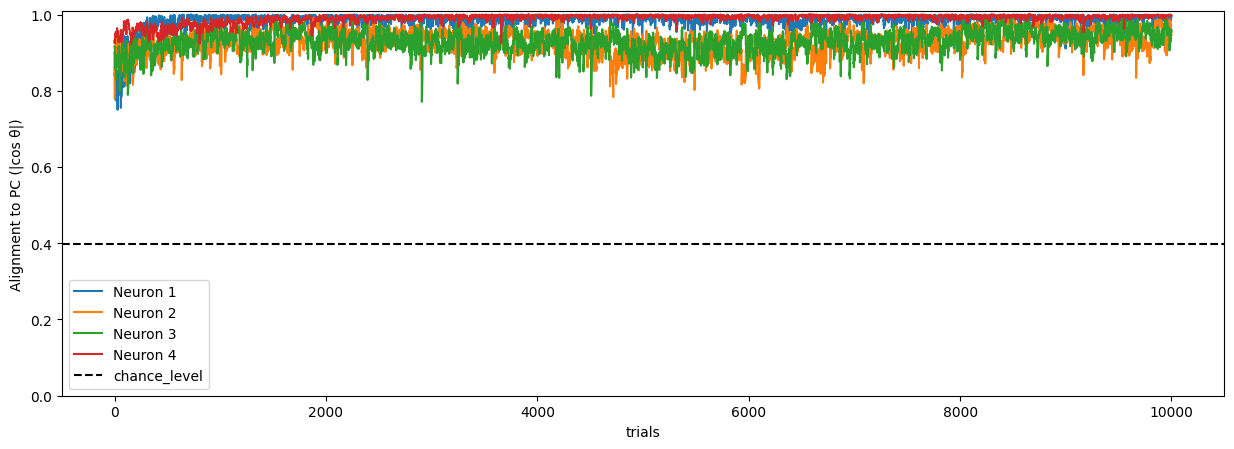

after second phase: model.W = [[ 0.06595454  0.03953353 -0.09715317 -0.00412763 -0.01891391 -0.04616934
  -0.03550095 -0.02986314  0.04337293 -0.06815708 -0.06680853 -0.21290812
  -0.07464833 -0.07638823  0.0573017   0.12095268 -0.03953166 -0.01034836
  -0.05827375 -0.21390703 -0.01002105 -0.08410582  0.02540614  0.12519821
  -0.06320223  0.03884785  0.08621386  0.07603379 -0.12374077 -0.15297234
   0.13496657  0.06836462 -0.03937601  0.0705102   0.08854902  0.1285048
   0.0996527  -0.08515188  0.18123121  0.10494563  0.05253758  0.06416853
  -0.02900999 -0.11347912  0.20689118 -0.11770964  0.23963325  0.02618534
  -0.12898775 -0.14600602 -0.06526219  0.15032104  0.04302895  0.12065892
   0.02190173 -0.06614354  0.13995207 -0.21418951  0.17235742 -0.05871746
   0.11153243  0.20804183  0.12043578  0.02178648]
 [ 0.13525919  0.18895976 -0.0986763  -0.02638739 -0.05096768 -0.27075588
  -0.17930295  0.1317493  -0.20198129  0.01932468  0.11065971 -0.02584236
  -0.13413534 -0.08863673  0.053

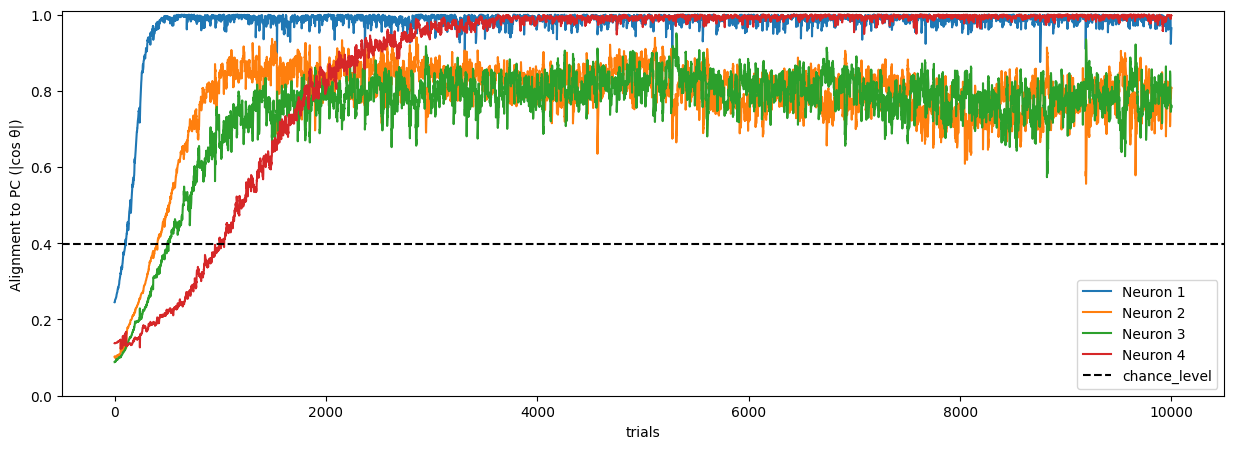

W after first phase: [[-0.09834993 -0.00200958  0.14173846  0.0821337   0.18870509 -0.12820029
  -0.23726546 -0.0818993   0.10682753 -0.10146049 -0.01313183  0.03304933
  -0.13733367 -0.17987666  0.0229919   0.19059613  0.00088909  0.01171587
   0.01908044 -0.10259747 -0.08246238 -0.06190489  0.1311638   0.2074579
  -0.15034147  0.01116868  0.15923361 -0.04228793 -0.17632175  0.01017577
   0.05657198 -0.06230295 -0.04361906  0.10404239 -0.18857021 -0.06005173
  -0.01613156  0.0196822  -0.11792333  0.13502488  0.07410042  0.21240675
   0.04824811 -0.20160909  0.06932882 -0.03520908  0.01566923 -0.06326904
  -0.06486175 -0.00538335  0.00386516 -0.02102037  0.0563352  -0.20938206
   0.10201197  0.07739548  0.19182115 -0.15015315 -0.00218763  0.01339007
   0.00224559  0.04070944 -0.02426386 -0.11836903]
 [ 0.12588263  0.08944958  0.0797929   0.07715709 -0.13681816 -0.15374447
  -0.13309542  0.1632216  -0.07624802 -0.03981005 -0.15746376 -0.01416245
  -0.02523295 -0.18626797  0.06243578 -0.

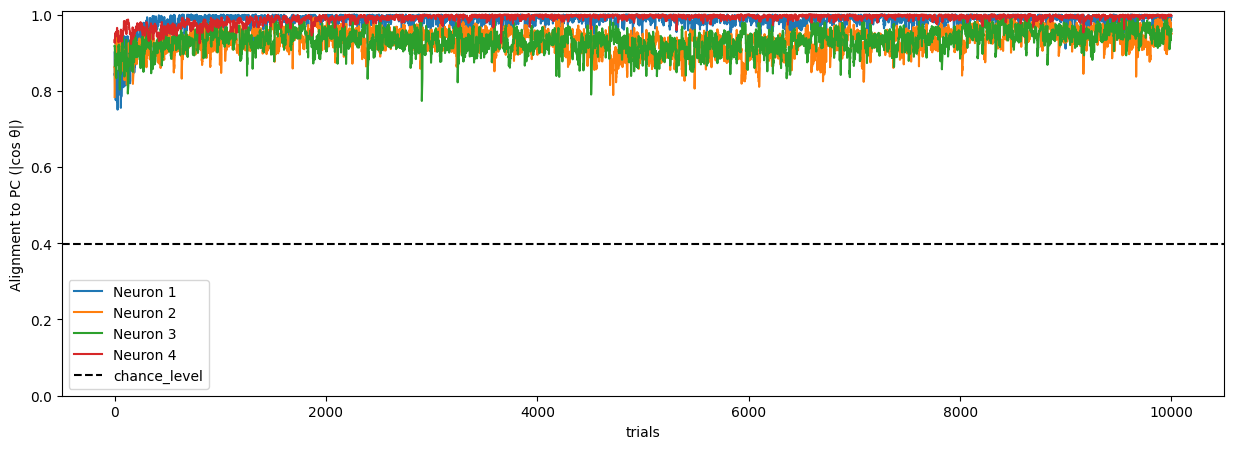

after second phase: model.W = [[-0.06669357  0.01118709  0.20271072  0.11531695  0.12904296 -0.15475044
  -0.26013213 -0.01041897  0.07485566 -0.09871325 -0.07416748  0.08074527
  -0.11177871 -0.22623674  0.03036592  0.15473187 -0.00244255  0.03597549
   0.03441468 -0.08960505 -0.03768262 -0.17169067  0.13393726  0.17902086
  -0.07356875 -0.04743432  0.0652567  -0.05543006 -0.18705943  0.03061322
   0.03745994 -0.11514004 -0.01311136  0.06715428 -0.12545344 -0.0780401
  -0.13981137  0.00782413 -0.06557456  0.02560185  0.07873516  0.13875145
   0.06013017 -0.22426686 -0.00277955 -0.01832393 -0.10285761 -0.00314608
  -0.00672315  0.02803115  0.0374412  -0.01085533  0.03747891 -0.27410769
   0.11115132  0.05902209  0.18984398 -0.10230743 -0.06352801  0.02025925
  -0.21397245 -0.01392787 -0.06568779 -0.18301091]
 [ 0.13108074  0.02456756  0.02194106  0.03654293 -0.21333846  0.01218695
   0.05992857  0.14834297 -0.05532183  0.00352755 -0.18435007 -0.04427068
   0.08768979 -0.05539151  0.033

<Figure size 640x480 with 0 Axes>

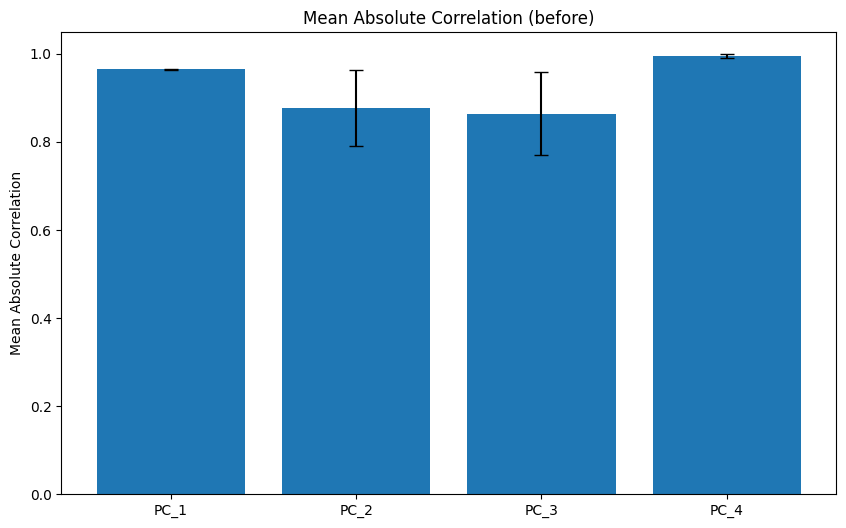

<Figure size 640x480 with 0 Axes>

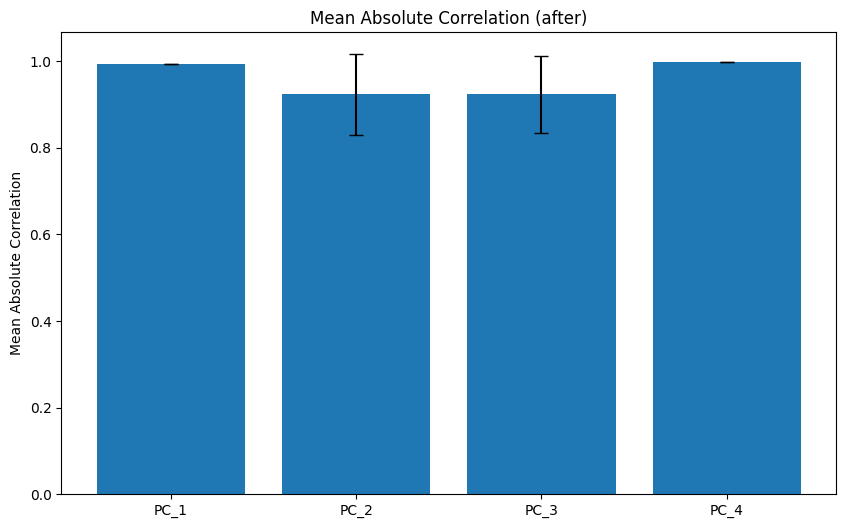

In [13]:
leen_model  = OneShotLeenCompletePCA(**model_paras)

leen_model = OneShotLeenReislebenPCA(**model_paras)

two_phase_training_testing(leen_model, X_before, X_after, m, model_paras_after = model_paras_after, runs = 10, graph = True)

### decoding task variable


### Chance level exploration with random vectors

In [ ]:
from hebbian.utils import pca_topk
from scipy.stats import pearsonr
from hebbian.utils import best_match_align_timeseries



def random_projection_chance_corr1(X, n_samples=1000, seed=None):
    """
    Calculate the expected absolute correlation between a random projection 
    of X and the PC projections of X.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    n_samples : int, default=1000
        Number of random vectors to sample for Monte Carlo estimation
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation between random projection and PC projections
    std_corr : float
        Standard deviation of correlations (for reference)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PCs
    _, _, PC_scores = pca_topk(X, d, center=True)
    print(f"shape of PC_scores: {PC_scores.shape}")
    
    # Sample random unit vectors
    rng = np.random.default_rng(seed)
    correlations = []
    
    for _ in range(n_samples):
        # Random unit vector in d-dimensional space
        w = rng.normal(size=d)
        w = w / (np.linalg.norm(w) + 1e-12)
        
        # Project X onto random direction
        y_random = Xc @ w
        
        # Compute correlation with each PC
        pc_corrs = []
        # print(f"shape of y_random: {y_random.shape}")
        
        # for j in range(min(d, PC_scores.shape[1])):
        # for j in range(2):
        # calculate the covariance between y_random and PC_scores[:, 0]
        cov = np.cov(y_random, PC_scores[:, 0])/np.cov(PC_scores[:, 0], PC_scores[:, 0])
        # pc_corrs.append(abs(r))
        pc_corrs.append(abs(cov[0, 1]))

        
        # Take max correlation (best match, like Hungarian algorithm does)
        correlations.append(max(pc_corrs))
    
    return np.mean(correlations), np.std(correlations)


def random_projection_chance_corr(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Calculate the expected absolute correlation between random projections 
    of X and the PC projections of X, using the same matching procedure
    as the actual analysis (best_match_align_timeseries).
    
    This generates m random unit vectors, projects X onto them, and uses
    Hungarian matching to find optimal alignment with PCs, just like the
    real analysis does.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    m : int, default=2
        Number of random projections (should match output_dim of your model)
    n_samples : int, default=1000
        Number of random vector sets to sample for Monte Carlo estimation
    metric : {"corr", "cosine"}, default="corr"
        Metric to use (should match what you use in best_match_align_timeseries)
    absolute : bool, default=True
        Whether to use absolute correlations (should match your usage)
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation after optimal matching
    std_corr : float
        Standard deviation of correlations (for reference)
    all_corrs : ndarray, shape (n_samples, m)
        All correlation values from each trial (for distribution analysis)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PC scores (top m PCs)
    _, _, PC_scores = pca_topk(X, d, center=True)
    PC_scores_m = PC_scores[:, :m]  # Use only top m PCs
    
    # Sample random projections
    rng = np.random.default_rng(seed)
    all_similarities = []
    
    for trial in range(n_samples):
        # Generate m random unit vectors in d-dimensional space
        W_random = rng.normal(size=(m, d))
        # Normalize each row to unit length
        W_random = W_random / (np.linalg.norm(W_random, axis=1, keepdims=True) + 1e-12)
        
        # Project X onto random directions: Y_random = Xc @ W_random.T
        # Shape: (n, d) @ (d, m) = (n, m)
        Y_random = Xc @ W_random.T
        
        # Use the same matching procedure as actual analysis
        perm, similarity, _, _ = best_match_align_timeseries(
            Y_random, PC_scores_m, 
            metric=metric, 
            absolute=absolute
        )
        
        # similarity is already the matched correlations
        all_similarities.append(similarity)
    
    all_similarities = np.array(all_similarities)  # Shape: (n_samples, m)
    
    # Compute statistics
    expected_corr = np.mean(all_similarities)
    std_corr = np.std(all_similarities)
    
    return expected_corr, std_corr, all_similarities


def random_projection_chance_corr_per_pc(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Same as random_projection_chance_corr but returns per-PC statistics.
    
    Returns
    -------
    expected_corr_per_pc : ndarray, shape (m,)
        Expected correlation for each PC (after sorting by PC order)
    std_corr_per_pc : ndarray, shape (m,)
        Standard deviation for each PC
    """
    expected_corr, std_corr, all_similarities = random_projection_chance_corr(
        X, m, n_samples, metric, absolute, seed
    )
    
    # Sort similarities by PC order (they're already matched, but we want PC1, PC2, ...)
    # The similarities are already optimally matched, so we sort them
    all_similarities_sorted = np.sort(all_similarities, axis=1)  # Sort each row
    
    expected_corr_per_pc = np.mean(all_similarities_sorted, axis=0)
    std_corr_per_pc = np.std(all_similarities_sorted, axis=0)
    
    return expected_corr_per_pc, std_corr_per_pc, all_similarities_sorted



def analytical_chance_corr(input_dim):
    """
    Analytical approximation for expected correlation between random projection
    and PC projection, assuming isotropic data (all eigenvalues equal).
    
    This is a simplified case. For non-isotropic data, use random_projection_chance_corr.
    
    Parameters
    ----------
    input_dim : int
        Input dimensionality
        
    Returns
    -------
    float 
        Expected absolute correlation (approximate)
    """
    # For isotropic case, this reduces to the random vector chance level
    # For non-isotropic, it's more complex and depends on eigenvalue distribution
    return np.sqrt(2 / (np.pi * input_dim))

In [ ]:
print(f"Analytical chance correlation: {analytical_chance_corr(N):.3f}")

In [ ]:
from hebbian.utils import generate_covariance_matrix
for i in range(2, 10, 1):
    N = i
    m = 2
    phi_deg = 45.0
    n_samples = 10001
    # get /sigma
    Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
    Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

    X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)
    print(f" input dimension = {N}")
    print(f"shape of X_before: {X_before.shape}")
    # In Y_aligned_training_testing_online or similar:
    expected_corr, std_corr = random_projection_chance_corr1(X_before, n_samples=1000)
    print(f"Expected chance correlation: {expected_corr:.3f} ± {std_corr:.3f}")

In [ ]:
# In your notebook or analysis:

# Or get per-PC statistics
expected_per_pc, std_per_pc, _ = random_projection_chance_corr_per_pc(
    X_before, m=2, n_samples=1000
)
print(f"Expected chance correlation per PC: PC1={expected_per_pc[0]:.3f}, PC2={expected_per_pc[1]:.3f}")